# Fine-Tuning Social-STGCNN — ECP Loss on zara2

**Goal:** Reduce collision rate on `zara2` while preserving ADE / FDE, by fine-tuning
the pre-trained baseline with a stronger ECP collision loss and larger `d_min`.

## Why `val_best.pth` alone is not enough

`val_best.pth` is saved based on **lowest NLL validation loss only** — no collision term.
This means it picks the epoch where the model best fits trajectory distribution, which is
typically the epoch where the collision-loss effect is **smallest** (the model has
partially recovered its NLL by learning to ignore the collision penalty).

To see the real collision-avoidance effect we therefore save and evaluate **two checkpoints** per run:

| Checkpoint | Saved when | What it captures |
|---|---|---|
| `val_best.pth` | Val NLL hits new minimum | Best trajectory accuracy — least collision benefit |
| `epoch_final.pth` | Last training epoch | Maximum collision-loss effect — some ADE/FDE cost |

Comparing the two reveals the true ADE vs CollisionRate tradeoff for each (d_min, lambda) config.

## Experiment grid

- **Loss:** ECP (acts on full predicted distribution, not just means)
- **d_min ∈ {0.2, 0.5, 1.0} m** — 0.2 m is the original threshold (almost never fires);
  0.5 m matches the real p1 pedestrian spacing (~100× more activations);
  1.0 m activates on ~10% of training pairs
- **lambda_col ∈ {5, 20}** — original lambda=1 was dominated by NLL; 5 is moderate, 20 is aggressive
- All 6 runs start from `baseline/social-stgcnn-zara2/val_best.pth`

| | lambda = 5 | lambda = 20 |
|---|---|---|
| d_min = 0.2 m | run 1 | run 2 |
| d_min = 0.5 m | run 3 | run 4 |
| d_min = 1.0 m | run 5 | run 6 |

**Before running:** Runtime → Change runtime type → **GPU** (T4 / L4 / A100).

## 1. Environment setup

In [1]:
!nvidia-smi
import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available(),
      '-', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')

Thu Apr 30 10:30:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   41C    P8             11W /  220W |     902MiB /  12282MiB |      9%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%pip install -q networkx tqdm pandas

Note: you may need to restart the kernel to use updated packages.


## 2. Mount Google Drive & set project directory

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# PROJECT_DIR = '/content/drive/MyDrive/DLproject-Social-STGCNN'
# assert os.path.isdir(PROJECT_DIR), f'Project not found at {PROJECT_DIR}'
# os.chdir(PROJECT_DIR)
# print('CWD:', os.getcwd() 

In [4]:
# Option C: Local machine
import os
PROJECT_DIR = r'D:\OMSCS\DLproject-Social-STGCNN'
assert os.path.isdir(PROJECT_DIR), f'Repo not found at {PROJECT_DIR}'
os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())
print('Files:', [f for f in os.listdir('.') if not f.startswith('.')])

Working directory: D:\OMSCS\DLproject-Social-STGCNN
Files: ["4.60'", 'architecture_diagram.pdf', 'architecture_diagram.png', 'baseline', 'baseline_results.csv', 'checkpoint', 'Colab_Baseline_Eval.ipynb', 'Colab_Collision1_hinge_Eval.ipynb', 'Colab_Collision2_exp_Eval.ipynb', 'Colab_Collision3_inv_Eval.ipynb', 'Colab_Collision4_gauss_Eval.ipynb', 'Colab_Collision5_ecp_Eval.ipynb', 'Colab_FineTune_zara2_ecp.ipynb', 'Colab_Train.ipynb', 'Collision_Aware_Trajectory_Prediction_Plan.md', 'collision_losses.py', 'datasets', 'ecp_d_02_lambda_1', 'exp_d_02_lambda_1', 'gauss_d_02_lambda_1', 'hinge_d_02_lambda_1', 'images', 'inv_d_02_lambda_1', 'LICENSE', 'metrics.py', 'mock_collision_demo.png', 'mock_collision_demo.py', 'model.py', 'README.MD', 'record.txt', 'requirements.txt', 'results_baseline_pretrained.txt', 'run_phase1.py', 'run_phase1_eval.py', 'scene_ped_metadata_hinge.csv', 'test.py', 'train.py', 'train.sh', 'train_phase1.sh', 'utils.py', '__pycache__']


## 3. Imports

In [5]:
import os, copy, pickle, math, glob
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.optim as optim
import torch.distributions.multivariate_normal as torchdist
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from model import social_stgcnn
from utils import TrajectoryDataset
from metrics import ade, fde, collision_metrics, seq_to_nodes, nodes_rel_to_nodes_abs
from collision_losses import collision_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 4. Experiment configuration

In [6]:
# ── Fixed settings ──────────────────────────────────────────────────────
DATASET         = 'zara2'
LOSS_FN         = 'ecp'
ECP_K           = 10
BASELINE_CKPT   = './baseline/social-stgcnn-zara2/val_best.pth'
BASELINE_ARGS   = './baseline/social-stgcnn-zara2/args.pkl'
FINETUNE_ROOT   = './finetune'
FINETUNE_EPOCHS = 100
FINETUNE_LR     = 0.001
BATCH_SIZE      = 128
KSTEPS          = 20
D_COL_EVAL      = 0.2   # evaluation collision radius — keep consistent with all prior results

# ── Sweep grid ───────────────────────────────────────────────────────────
D_MIN_LIST   = [0.2, 0.5, 1.0]
LAMBDA_LIST  = [5, 10, 20]

CONFIGS = [
    {'d_min': d, 'lambda_col': l}
    for d in D_MIN_LIST
    for l in LAMBDA_LIST
]

def run_tag(cfg):
    return f'social-stgcnn-{DATASET}-{LOSS_FN}-dmin{cfg["d_min"]}-lam{cfg["lambda_col"]}'

def run_dir(cfg):
    return os.path.join(FINETUNE_ROOT, run_tag(cfg))

print(f'Fine-tuning {len(CONFIGS)} configs on {DATASET} with {LOSS_FN} loss:')
for c in CONFIGS:
    print(f'  d_min={c["d_min"]}  lambda_col={c["lambda_col"]}  ->  {run_dir(c)}')

Fine-tuning 9 configs on zara2 with ecp loss:
  d_min=0.2  lambda_col=5  ->  ./finetune\social-stgcnn-zara2-ecp-dmin0.2-lam5
  d_min=0.2  lambda_col=10  ->  ./finetune\social-stgcnn-zara2-ecp-dmin0.2-lam10
  d_min=0.2  lambda_col=20  ->  ./finetune\social-stgcnn-zara2-ecp-dmin0.2-lam20
  d_min=0.5  lambda_col=5  ->  ./finetune\social-stgcnn-zara2-ecp-dmin0.5-lam5
  d_min=0.5  lambda_col=10  ->  ./finetune\social-stgcnn-zara2-ecp-dmin0.5-lam10
  d_min=0.5  lambda_col=20  ->  ./finetune\social-stgcnn-zara2-ecp-dmin0.5-lam20
  d_min=1.0  lambda_col=5  ->  ./finetune\social-stgcnn-zara2-ecp-dmin1.0-lam5
  d_min=1.0  lambda_col=10  ->  ./finetune\social-stgcnn-zara2-ecp-dmin1.0-lam10
  d_min=1.0  lambda_col=20  ->  ./finetune\social-stgcnn-zara2-ecp-dmin1.0-lam20


## 5. Load shared data loaders

Also verifies how many training pairs fall within each `d_min` threshold — this confirms
the collision loss will actually fire during training.

In [7]:
data_root = f'./datasets/{DATASET}/'

with open(BASELINE_ARGS, 'rb') as f:
    base_args = pickle.load(f)

obs_len  = base_args.obs_seq_len   # 8
pred_len = base_args.pred_seq_len  # 12

print("obs_len:", obs_len)
print("pred_len:", pred_len)

print('Building datasets ...', flush=True)
dset_train = TrajectoryDataset(data_root+'train/', obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)
dset_val   = TrajectoryDataset(data_root+'val/',   obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)
dset_test  = TrajectoryDataset(data_root+'test/',  obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)

loader_train = DataLoader(dset_train, batch_size=1, shuffle=True,  num_workers=0)
loader_val   = DataLoader(dset_val,   batch_size=1, shuffle=False, num_workers=0)
loader_test  = DataLoader(dset_test,  batch_size=1, shuffle=False, num_workers=0)

print(f'Train: {len(dset_train)}  Val: {len(dset_val)}  Test: {len(dset_test)} scenes')

# How many training pairs fall inside each d_min? — confirms the loss will fire
print('\nPairwise distance coverage in training data:')
all_dists = []
for path in glob.glob(data_root + 'train/*.txt'):
    raw = np.loadtxt(path)
    for fr in np.unique(raw[:, 0]):
        xy = raw[raw[:, 0] == fr][:, 2:]
        N = len(xy)
        for i in range(N):
            for j in range(i+1, N):
                all_dists.append(np.linalg.norm(xy[i] - xy[j]))
all_dists = np.array(all_dists)
print(f'  Total ped pairs : {len(all_dists):,}')
for thr in [0.2, 0.5, 1.0]:
    n = (all_dists < thr).sum()
    print(f'  Pairs < {thr} m  : {n:5d}  ({100*n/len(all_dists):.3f}%)')

obs_len: 8
pred_len: 12
Building datasets ...
Processing Data ..... (2112/2112)
Processing Data ..... (501/501)
Processing Data ..... (921/921)
Train: 2112  Val: 501  Test: 921 scenes

Pairwise distance coverage in training data:
  Total ped pairs : 823,220
  Pairs < 0.2 m  :    64  (0.008%)
  Pairs < 0.5 m  :  5108  (0.620%)
  Pairs < 1.0 m  : 29278  (3.557%)


## 6. Model builder

In [8]:
def build_model_from_baseline():
    m = social_stgcnn(
        n_stgcnn    = base_args.n_stgcnn,
        n_txpcnn    = base_args.n_txpcnn,
        output_feat = base_args.output_size,
        seq_len     = base_args.obs_seq_len,
        kernel_size = base_args.kernel_size,
        pred_seq_len= base_args.pred_seq_len,
    ).to(device)
    m.load_state_dict(torch.load(BASELINE_CKPT, map_location=device))
    return m

_m = build_model_from_baseline()
print(f'Model parameters: {sum(p.numel() for p in _m.parameters()):,}')
del _m

Model parameters: 7,668


## 7. Fine-tuning function

**Two checkpoints are saved per run:**
- `val_best.pth`    — epoch with lowest val NLL (best trajectory accuracy)
- `epoch_final.pth` — weights after the very last epoch (maximum collision-loss effect)

Validation always uses NLL only — consistent with the baseline — so `val_best.pth` picks
the most accurate model, not the most collision-aware one.  `epoch_final.pth` gives the
other end of the tradeoff.

In [9]:
from IPython.display import clear_output

def bivariate_loss(V_pred, V_trgt):
    normx = V_trgt[:,:,0] - V_pred[:,:,0]
    normy = V_trgt[:,:,1] - V_pred[:,:,1]
    sx    = torch.exp(V_pred[:,:,2])
    sy    = torch.exp(V_pred[:,:,3])
    corr  = torch.tanh(V_pred[:,:,4])
    sxsy  = sx * sy
    z     = (normx/sx)**2 + (normy/sy)**2 - 2*corr*normx*normy/sxsy
    negRho = 1 - corr**2
    result = torch.exp(-z / (2*negRho))
    denom  = 2 * math.pi * sxsy * torch.sqrt(negRho)
    return -torch.log(torch.clamp(result/denom, min=1e-20)).mean()


def _plot_live(history, best, tag, epoch, total_epochs, save_path=None):
    """Draw (or redraw) the live loss curve for the current run."""
    ep = range(len(history['train_nll']))
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(ep, history['train_nll'], label='Train NLL',
            color='steelblue', linewidth=1.8)
    ax.plot(ep, history['train_col'], label='Train ECP (unscaled)',
            color='darkorange', linewidth=1.8, linestyle='--')
    ax.plot(ep, history['val_loss'],  label='Val NLL',
            color='crimson',   linewidth=1.8, linestyle=':')

    if best['epoch'] >= 0:
        ax.axvline(best['epoch'], color='green', linestyle=':', linewidth=1.2,
                   alpha=0.8, label=f'val_best saved (ep {best["epoch"]})')

    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss',  fontsize=10)
    ax.set_title(f'{tag}  —  epoch {epoch+1}/{total_epochs}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')

    plt.show()


PLOT_EVERY = 10   # redraw the live curve every N epochs


def fine_tune(cfg, verbose=True):
    d_min      = cfg['d_min']
    lambda_col = cfg['lambda_col']
    tag        = run_tag(cfg)
    ckpt_dir   = run_dir(cfg)
    os.makedirs(ckpt_dir, exist_ok=True)

    model     = build_model_from_baseline()
    optimizer = optim.SGD(model.parameters(), lr=FINETUNE_LR)

    history = {'train_loss': [], 'train_nll': [], 'train_col': [], 'val_loss': []}
    best    = {'epoch': -1, 'val_loss': float('inf')}

    # Persist args so evaluate_model() can reload this checkpoint
    saved_args = copy.deepcopy(base_args)
    saved_args.collision_loss = LOSS_FN
    saved_args.lambda_col     = lambda_col
    saved_args.d_min          = d_min
    saved_args.ecp_k          = ECP_K
    with open(os.path.join(ckpt_dir, 'args.pkl'), 'wb') as f:
        pickle.dump(saved_args, f)

    loader_len = len(loader_train)
    # turn_point: index of last batch — ensures the final partial mini-batch
    # is always included in an optimizer step (mirrors train.py behaviour)
    turn_point = int(loader_len/BATCH_SIZE)*BATCH_SIZE + loader_len%BATCH_SIZE - 1

    for epoch in range(FINETUNE_EPOCHS):

        # ── Train ─────────────────────────────────────────────────────
        model.train()
        loss_sum = nll_sum = col_sum = 0.0
        n_updates = batch_count = 0
        is_fst = True

        for cnt, batch in enumerate(loader_train):
            batch_count += 1
            batch = [t.to(device) for t in batch]
            obs_traj, _, _, _, _, _, V_obs, A_obs, V_tr, _ = batch

            optimizer.zero_grad()
            V_pred, _ = model(V_obs.permute(0,3,1,2), A_obs.squeeze())
            V_pred = V_pred.permute(0,2,3,1).squeeze()
            V_tr   = V_tr.squeeze()

            start_pos = obs_traj[0, :, :, -1]   # (N, 2) last observed absolute position
            l_nll = bivariate_loss(V_pred, V_tr)
            l_col = collision_loss(LOSS_FN, V_pred, start_pos, d_min=d_min, K=ECP_K)
            l     = l_nll + lambda_col * l_col

            if batch_count % BATCH_SIZE != 0 and cnt != turn_point:
                if is_fst: loss_acc = l; nll_acc = l_nll; col_acc = l_col; is_fst = False
                else:       loss_acc += l; nll_acc += l_nll; col_acc += l_col
            else:
                (loss_acc / BATCH_SIZE).backward()
                optimizer.step()
                loss_sum += (loss_acc / BATCH_SIZE).item()
                nll_sum  += (nll_acc  / BATCH_SIZE).item()
                col_sum  += (col_acc  / BATCH_SIZE).item()
                n_updates += 1
                is_fst = True

        n_updates = max(n_updates, 1)
        history['train_loss'].append(loss_sum / n_updates)
        history['train_nll'].append(nll_sum   / n_updates)
        history['train_col'].append(col_sum   / n_updates)

        # ── Validate (NLL only — same criterion as baseline) ───────────
        model.eval()
        vl_sum = vl_acc = 0.0
        v_updates = v_count = 0
        is_fst = True
        vloader_len = len(loader_val)
        v_turn = int(vloader_len/BATCH_SIZE)*BATCH_SIZE + vloader_len%BATCH_SIZE - 1

        with torch.no_grad():
            for cnt, batch in enumerate(loader_val):
                v_count += 1
                batch = [t.to(device) for t in batch]
                _, _, _, _, _, _, V_obs, A_obs, V_tr, _ = batch
                V_pred, _ = model(V_obs.permute(0,3,1,2), A_obs.squeeze())
                V_pred = V_pred.permute(0,2,3,1).squeeze()
                l = bivariate_loss(V_pred, V_tr.squeeze())
                if v_count % BATCH_SIZE != 0 and cnt != v_turn:
                    if is_fst: vl_acc = l; is_fst = False
                    else:       vl_acc += l
                else:
                    vl_sum += (vl_acc / BATCH_SIZE).item()
                    v_updates += 1; is_fst = True

        avg_val = vl_sum / max(v_updates, 1)
        history['val_loss'].append(avg_val)

        # ── Checkpoint: best NLL ───────────────────────────────────────
        if avg_val < best['val_loss']:
            best['val_loss'] = avg_val
            best['epoch']    = epoch
            torch.save(model.state_dict(), os.path.join(ckpt_dir, 'val_best.pth'))

        # ── Checkpoint: final epoch (always overwrite) ─────────────────
        torch.save(model.state_dict(), os.path.join(ckpt_dir, 'epoch_final.pth'))

        # ── Live loss plot ─────────────────────────────────────────────
        is_last = (epoch == FINETUNE_EPOCHS - 1)
        if verbose and (epoch % PLOT_EVERY == 0 or is_last):
            clear_output(wait=True)
            print(f'Run {tag}')
            print(f'  ep {epoch+1:3d}/{FINETUNE_EPOCHS}  '
                  f'nll={history["train_nll"][-1]:.5f}  '
                  f'col={history["train_col"][-1]:.5f}  '
                  f'val={avg_val:.5f}  '
                  f'best_val_ep={best["epoch"]}')
            save_path = os.path.join(ckpt_dir, 'training_curve.png') if is_last else None
            _plot_live(history, best, tag, epoch, FINETUNE_EPOCHS, save_path=save_path)

    with open(os.path.join(ckpt_dir, 'metrics.pkl'),          'wb') as f: pickle.dump(history, f)
    with open(os.path.join(ckpt_dir, 'constant_metrics.pkl'), 'wb') as f: pickle.dump(best, f)

    print(f'Saved  val_best (ep {best["epoch"]})  +  epoch_final  ->  {ckpt_dir}')
    return history

print('fine_tune() defined.  PLOT_EVERY =', PLOT_EVERY)

fine_tune() defined.  PLOT_EVERY = 10


## 8. Evaluation helper

In [10]:
def evaluate_model(model_path, K=KSTEPS, d_col=D_COL_EVAL):
    """Evaluate a single checkpoint on the zara2 test set."""
    ckpt_dir = os.path.dirname(model_path)
    with open(os.path.join(ckpt_dir, 'args.pkl'), 'rb') as f:
        args = pickle.load(f)

    m = social_stgcnn(
        n_stgcnn=args.n_stgcnn, n_txpcnn=args.n_txpcnn,
        output_feat=args.output_size, seq_len=args.obs_seq_len,
        kernel_size=args.kernel_size, pred_seq_len=args.pred_seq_len,
    ).to(device)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.eval()

    ade_ls, fde_ls, col_avg_ls, col_minade_ls = [], [], [], []

    with torch.no_grad():
        for batch in loader_test:
            batch = [t.to(device) for t in batch]
            obs_traj, _, obs_traj_rel, _, _, _, V_obs, A_obs, V_tr, _ = batch
            num_objs = obs_traj_rel.shape[1]

            V_pred, _ = m(V_obs.permute(0,3,1,2), A_obs.squeeze())
            V_pred = V_pred.permute(0,2,3,1).squeeze()[:, :num_objs, :]
            V_tr   = V_tr.squeeze()[:, :num_objs, :]

            sx   = torch.exp(V_pred[:,:,2])
            sy   = torch.exp(V_pred[:,:,3])
            corr = torch.tanh(V_pred[:,:,4])
            cov  = torch.zeros(*V_pred.shape[:2], 2, 2, device=device)
            cov[:,:,0,0] = sx*sx; cov[:,:,0,1] = corr*sx*sy
            cov[:,:,1,0] = corr*sx*sy; cov[:,:,1,1] = sy*sy
            mvn = torchdist.MultivariateNormal(V_pred[:,:,:2], cov)

            V_x     = seq_to_nodes(obs_traj.cpu().numpy().copy())
            V_x_abs = nodes_rel_to_nodes_abs(
                V_obs.cpu().numpy().squeeze().copy(), V_x[0].copy())
            V_y_abs = nodes_rel_to_nodes_abs(
                V_tr.cpu().numpy().squeeze().copy(), V_x[-1].copy())

            ade_pp = {n: [] for n in range(num_objs)}
            fde_pp = {n: [] for n in range(num_objs)}
            samples_scene = []

            for _ in range(K):
                samp_abs = nodes_rel_to_nodes_abs(
                    mvn.sample().cpu().numpy().squeeze().copy(), V_x[-1].copy())
                samples_scene.append(samp_abs[:, :num_objs, :])
                for n in range(num_objs):
                    ade_pp[n].append(ade([samp_abs[:,n:n+1,:]], [V_y_abs[:,n:n+1,:]], [1]))
                    fde_pp[n].append(fde([samp_abs[:,n:n+1,:]], [V_y_abs[:,n:n+1,:]], [1]))

            for n in range(num_objs):
                ade_ls.append(min(ade_pp[n]))
                fde_ls.append(min(fde_pp[n]))

            col = collision_metrics(samples_scene, V_y_abs[:,:num_objs,:], d_col=d_col)
            col_avg_ls.append(col['ColRate_avg'])
            col_minade_ls.append(col['ColRate_minADE'])

    return {
        'ADE':            sum(ade_ls)        / len(ade_ls),
        'FDE':            sum(fde_ls)        / len(fde_ls),
        'ColRate_avg':    sum(col_avg_ls)    / len(col_avg_ls),
        'ColRate_minADE': sum(col_minade_ls) / len(col_minade_ls),
    }

print('evaluate_model() defined.')

evaluate_model() defined.


## 9. Run fine-tuning

6 configs × ~10-15 min each on T4.  Estimated total: **~1–1.5 hours**.

Run social-stgcnn-zara2-ecp-dmin1.0-lam20
  ep 100/100  nll=-1.21989  col=0.03187  val=-1.31407  best_val_ep=85


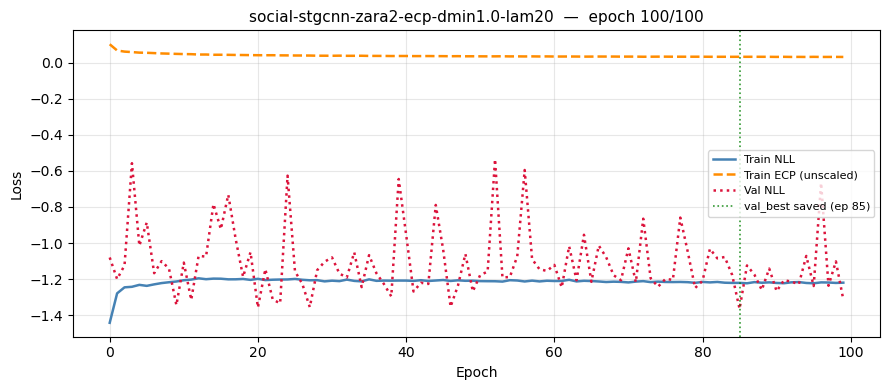

Saved  val_best (ep 85)  +  epoch_final  ->  ./finetune\social-stgcnn-zara2-ecp-dmin1.0-lam20

All fine-tuning runs complete.


In [11]:
all_histories = {}

for i, cfg in enumerate(CONFIGS):
    sep = '='*60
    print(f'\n{sep}')
    print(f'Config {i+1}/{len(CONFIGS)}: d_min={cfg["d_min"]}  lambda_col={cfg["lambda_col"]}')
    print(sep)
    hist = fine_tune(cfg, verbose=True)
    all_histories[run_tag(cfg)] = hist

print('\nAll fine-tuning runs complete.')

## 10. Training curve summary (all runs)

Loss curves were shown live during training (every `PLOT_EVERY` epochs) and the final
curve per run was saved to `<ckpt_dir>/training_curve.png`.

This cell loads all saved PNGs and shows them in one grid for easy comparison.

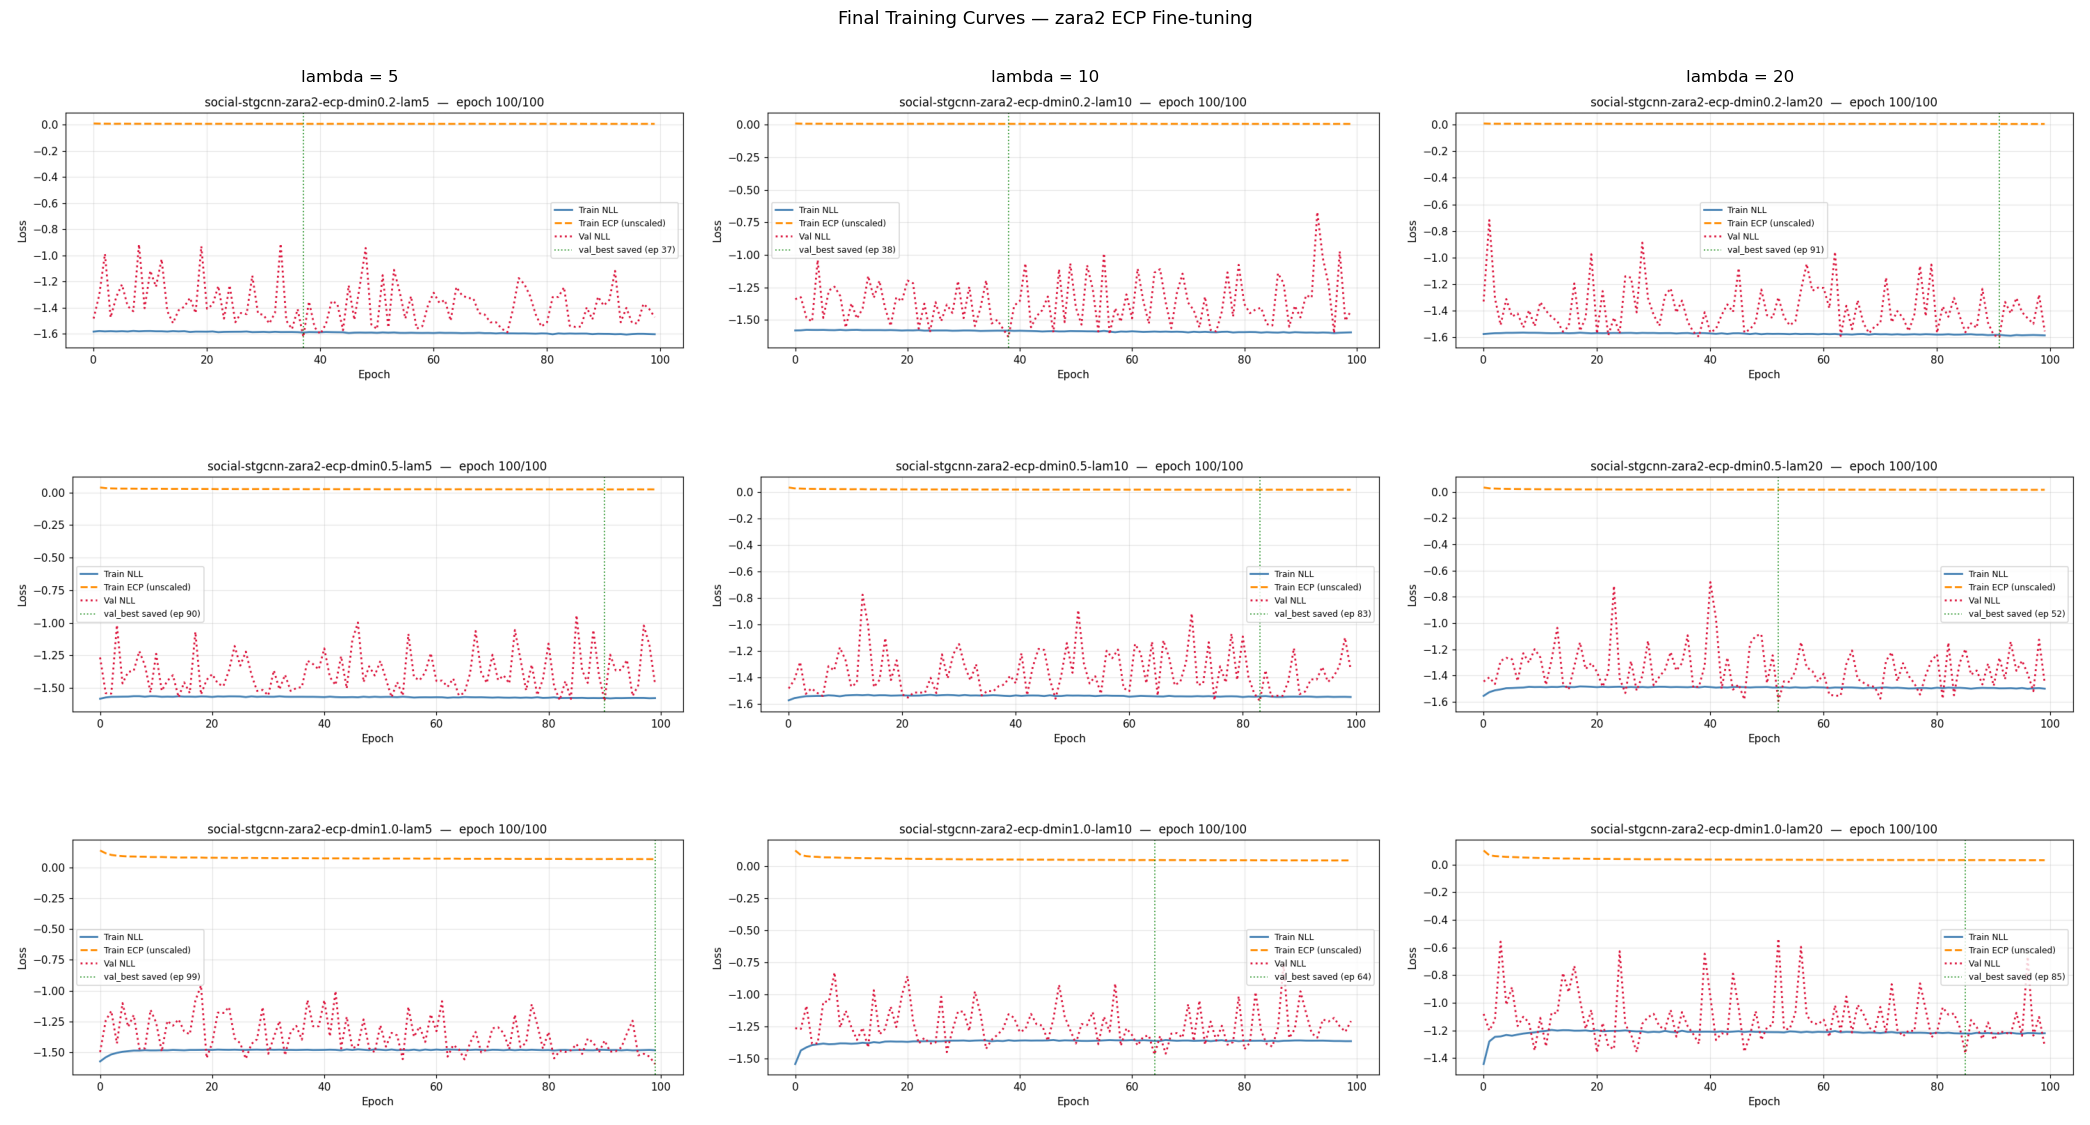

Saved finetune_training_curves_grid.png


In [12]:
from matplotlib.image import imread

n_cols = len(LAMBDA_LIST)   # one column per lambda value
n_rows = len(D_MIN_LIST)    # one row per d_min value
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(7 * n_cols, 4 * n_rows), squeeze=False)

for row_i, d_min in enumerate(D_MIN_LIST):
    for col_i, lam in enumerate(LAMBDA_LIST):
        cfg = {'d_min': d_min, 'lambda_col': lam}
        png = os.path.join(run_dir(cfg), 'training_curve.png')
        ax  = axes[row_i][col_i]
        if os.path.exists(png):
            ax.imshow(imread(png))
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, f'Not found:\n{png}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8)
            ax.axis('off')
        if row_i == 0:
            ax.set_title(f'lambda = {lam}', fontsize=12, pad=6)
        if col_i == 0:
            ax.set_ylabel(f'd_min = {d_min} m', fontsize=11, labelpad=8)

fig.suptitle('Final Training Curves — zara2 ECP Fine-tuning', fontsize=13)
plt.tight_layout()
plt.savefig('finetune_training_curves_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved finetune_training_curves_grid.png')

## 11. Evaluate all checkpoints

For each config we evaluate **two** checkpoints:
- `val_best.pth`    — best NLL epoch (most accurate, least collision benefit)
- `epoch_final.pth` — last training epoch (most collision benefit, some ADE cost)

In [13]:
results = []

# ── Baseline ────────────────────────────────────────────────────────────
print('Evaluating baseline ...')
r = evaluate_model(BASELINE_CKPT)
r.update({'Model': 'Baseline', 'Checkpoint': 'val_best',
          'd_min': None, 'lambda_col': None})
results.append(r)
print(f'  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}  '
      f'ColRate_avg={r["ColRate_avg"]:.4f}  ColRate_minADE={r["ColRate_minADE"]:.4f}')

# ── Fine-tuned: both checkpoints ────────────────────────────────────────
for cfg in CONFIGS:
    for ckpt_file, ckpt_label in [('val_best.pth',    'best NLL'),
                                   ('epoch_final.pth', 'final ep')]:
        path = os.path.join(run_dir(cfg), ckpt_file)
        lbl  = f'ECP d={cfg["d_min"]} lam={cfg["lambda_col"]} [{ckpt_label}]'
        print(f'Evaluating {lbl} ...')
        r = evaluate_model(path)
        r.update({'Model': lbl, 'Checkpoint': ckpt_label,
                  'd_min': cfg['d_min'], 'lambda_col': cfg['lambda_col']})
        results.append(r)
        print(f'  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}  '
              f'ColRate_avg={r["ColRate_avg"]:.4f}  ColRate_minADE={r["ColRate_minADE"]:.4f}')

df = pd.DataFrame(results).set_index('Model')
for col in ['ADE','FDE','ColRate_avg','ColRate_minADE']:
    df[col] = pd.to_numeric(df[col])

base_ade = df.loc['Baseline', 'ADE']
base_fde = df.loc['Baseline', 'FDE']
base_col = df.loc['Baseline', 'ColRate_avg']
df['ΔADE']     = df['ADE']          - base_ade
df['ΔFDE']     = df['FDE']          - base_fde
df['ΔColRate']  = df['ColRate_avg'] - base_col

print('\nDone.')

Evaluating baseline ...
  ADE=0.3048  FDE=0.4975  ColRate_avg=0.4292  ColRate_minADE=0.4148
Evaluating ECP d=0.2 lam=5 [best NLL] ...
  ADE=0.3062  FDE=0.4990  ColRate_avg=0.4267  ColRate_minADE=0.3909
Evaluating ECP d=0.2 lam=5 [final ep] ...
  ADE=0.3118  FDE=0.4988  ColRate_avg=0.4009  ColRate_minADE=0.3996
Evaluating ECP d=0.2 lam=10 [best NLL] ...
  ADE=0.3077  FDE=0.5075  ColRate_avg=0.4160  ColRate_minADE=0.4007
Evaluating ECP d=0.2 lam=10 [final ep] ...
  ADE=0.3152  FDE=0.5018  ColRate_avg=0.4175  ColRate_minADE=0.3800
Evaluating ECP d=0.2 lam=20 [best NLL] ...
  ADE=0.3102  FDE=0.5110  ColRate_avg=0.4081  ColRate_minADE=0.3474
Evaluating ECP d=0.2 lam=20 [final ep] ...
  ADE=0.3115  FDE=0.4996  ColRate_avg=0.4356  ColRate_minADE=0.4104
Evaluating ECP d=0.5 lam=5 [best NLL] ...
  ADE=0.3170  FDE=0.5267  ColRate_avg=0.4302  ColRate_minADE=0.4007
Evaluating ECP d=0.5 lam=5 [final ep] ...
  ADE=0.3208  FDE=0.5164  ColRate_avg=0.4246  ColRate_minADE=0.4159
Evaluating ECP d=0.5 lam

## 12. Results table

In [14]:
display_cols = ['Checkpoint','ADE','FDE','ColRate_avg','ColRate_minADE','ΔADE','ΔFDE','ΔColRate']
fmt = {'ADE':'{:.4f}','FDE':'{:.4f}',
       'ColRate_avg':'{:.4f}','ColRate_minADE':'{:.4f}',
       'ΔADE':'{:+.4f}','ΔFDE':'{:+.4f}','ΔColRate':'{:+.4f}'}

styled = (df[display_cols]
    .style
    .format(fmt)
    .background_gradient(subset=['ColRate_avg'], cmap='RdYlGn_r')
    .background_gradient(subset=['ADE'],         cmap='RdYlGn_r')
    .set_caption(
        'zara2 test results — val_best vs epoch_final for each config.\n'
        'val_best = best NLL checkpoint; epoch_final = last training epoch.')
)
display(styled)

,Checkpoint,ADE,FDE,ColRate_avg,ColRate_minADE,ΔADE,ΔFDE,ΔColRate
Model,,,,,,,,
Baseline,val_best,0.3048,0.4975,0.4292,0.4148,+0.0000,+0.0000,+0.0000
ECP d=0.2 lam=5 [best NLL],best NLL,0.3062,0.4990,0.4267,0.3909,+0.0013,+0.0015,-0.0024
ECP d=0.2 lam=5 [final ep],final ep,0.3118,0.4988,0.4009,0.3996,+0.0070,+0.0013,-0.0283
ECP d=0.2 lam=10 [best NLL],best NLL,0.3077,0.5075,0.4160,0.4007,+0.0029,+0.0100,-0.0132
ECP d=0.2 lam=10 [final ep],final ep,0.3152,0.5018,0.4175,0.3800,+0.0103,+0.0043,-0.0117
ECP d=0.2 lam=20 [best NLL],best NLL,0.3102,0.5110,0.4081,0.3474,+0.0053,+0.0135,-0.0211
ECP d=0.2 lam=20 [final ep],final ep,0.3115,0.4996,0.4356,0.4104,+0.0066,+0.0021,+0.0064
ECP d=0.5 lam=5 [best NLL],best NLL,0.3170,0.5267,0.4302,0.4007,+0.0121,+0.0292,+0.0011
ECP d=0.5 lam=5 [final ep],final ep,0.3208,0.5164,0.4246,0.4159,+0.0159,+0.0188,-0.0046


## 13. Tradeoff plot: Collision Rate vs ADE / FDE

- `val_best` checkpoints: **filled** markers
- `epoch_final` checkpoints: **open** markers (same colour/shape)

The arrow from filled to open shows the collision-avoidance gain at the cost of accuracy.
The ideal region is **bottom-left** of the baseline star.

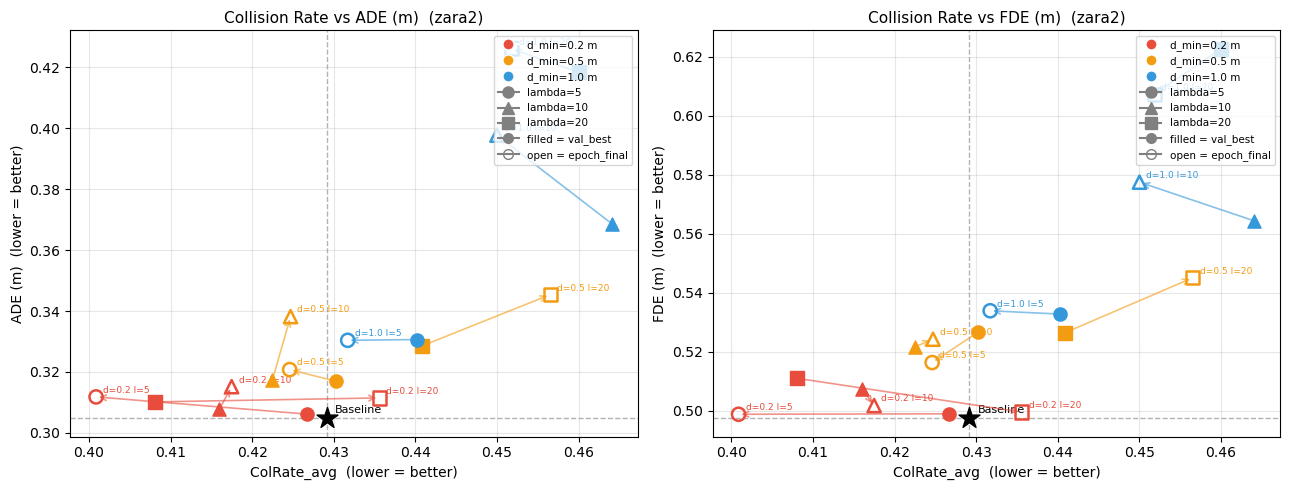

Saved finetune_tradeoff.png


In [15]:
# colour = d_min, marker = lambda_col — must match CONFIGS exactly
col_map    = {0.2: '#e74c3c', 0.5: '#f39c12', 1.0: '#3498db'}
marker_map = {5: 'o', 10: '^', 20: 's'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_col, y_lbl in [(axes[0], 'ADE', 'ADE (m)'), (axes[1], 'FDE', 'FDE (m)')]:

    bx = df.loc['Baseline', 'ColRate_avg']
    by = df.loc['Baseline', y_col]
    ax.axvline(bx, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(by, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.scatter([bx], [by], marker='*', s=250, color='black', zorder=6, label='Baseline')
    ax.annotate('Baseline', (bx, by), xytext=(6, 4), textcoords='offset points', fontsize=8)

    for cfg in CONFIGS:
        c  = col_map[cfg['d_min']]
        mk = marker_map[cfg['lambda_col']]

        lbl_best  = f'ECP d={cfg["d_min"]} lam={cfg["lambda_col"]} [best NLL]'
        lbl_final = f'ECP d={cfg["d_min"]} lam={cfg["lambda_col"]} [final ep]'

        rx_best  = df.loc[lbl_best,  'ColRate_avg'];  ry_best  = df.loc[lbl_best,  y_col]
        rx_final = df.loc[lbl_final, 'ColRate_avg'];  ry_final = df.loc[lbl_final, y_col]

        # Arrow: val_best (filled) -> epoch_final (open)
        ax.annotate('', xy=(rx_final, ry_final), xytext=(rx_best, ry_best),
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.2, alpha=0.6))
        ax.scatter([rx_best],  [ry_best],  color=c, marker=mk, s=90, zorder=5)
        ax.scatter([rx_final], [ry_final], facecolors='none', edgecolors=c,
                   marker=mk, s=90, linewidths=1.8, zorder=5)
        ax.annotate(f'd={cfg["d_min"]} l={cfg["lambda_col"]}',
                    (rx_final, ry_final), xytext=(5, 3),
                    textcoords='offset points', fontsize=6.5, color=c)

    ax.set_xlabel('ColRate_avg  (lower = better)', fontsize=10)
    ax.set_ylabel(f'{y_lbl}  (lower = better)', fontsize=10)
    ax.set_title(f'Collision Rate vs {y_lbl}  (zara2)', fontsize=11)
    ax.grid(True, alpha=0.3)

    legend_els = (
        [Line2D([0],[0], marker='o', color='w', markerfacecolor=v,
                markersize=8, label=f'd_min={k} m') for k, v in col_map.items()] +
        [Line2D([0],[0], marker=v, color='gray',
                markersize=8, label=f'lambda={k}') for k, v in marker_map.items()] +
        [Line2D([0],[0], marker='o', color='gray', markersize=7,
                label='filled = val_best'),
         Line2D([0],[0], marker='o', color='gray', markersize=7,
                fillstyle='none', label='open = epoch_final')]
    )
    ax.legend(handles=legend_els, fontsize=7.5, loc='upper right')

plt.tight_layout()
plt.savefig('finetune_tradeoff.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved finetune_tradeoff.png')

## 14. Summary: best config

Find the config + checkpoint that reduces collision rate the most while keeping ΔADE < +0.05 m.

In [16]:
ADE_BUDGET = 0.05   # max allowed ADE increase over baseline

candidates = df[(df['ΔADE'] <= ADE_BUDGET) & (df.index != 'Baseline')].copy()

if candidates.empty:
    print(f'No config reduces collision rate within ΔADE <= {ADE_BUDGET} m.')
    print('Consider relaxing ADE_BUDGET or reducing FINETUNE_EPOCHS.')
else:
    best_cfg = candidates['ΔColRate'].idxmin()
    row = candidates.loc[best_cfg]
    print(f'Best config within ΔADE <= {ADE_BUDGET} m:')
    print(f'  Model       : {best_cfg}')
    print(f'  ADE         : {row["ADE"]:.4f}  (ΔADE={row["ΔADE"]:+.4f})')
    print(f'  FDE         : {row["FDE"]:.4f}  (ΔFDE={row["ΔFDE"]:+.4f})')
    print(f'  ColRate_avg : {row["ColRate_avg"]:.4f}  (ΔColRate={row["ΔColRate"]:+.4f})')
    print(f'  ColRate_minADE: {row["ColRate_minADE"]:.4f}')

Best config within ΔADE <= 0.05 m:
  Model       : ECP d=0.2 lam=5 [final ep]
  ADE         : 0.3118  (ΔADE=+0.0070)
  FDE         : 0.4988  (ΔFDE=+0.0013)
  ColRate_avg : 0.4009  (ΔColRate=-0.0283)
  ColRate_minADE: 0.3996


## 15. Save results & persist to Drive

In [17]:
df.to_csv('finetune_zara2_ecp_results.csv')
print('Saved finetune_zara2_ecp_results.csv')
print(df[['Checkpoint','ADE','FDE','ColRate_avg','ΔADE','ΔFDE','ΔColRate']].to_string())

Saved finetune_zara2_ecp_results.csv
                            Checkpoint       ADE       FDE  ColRate_avg      ΔADE      ΔFDE  ΔColRate
Model                                                                                                
Baseline                      val_best  0.304847  0.497541     0.429153  0.000000  0.000000  0.000000
ECP d=0.2 lam=5 [best NLL]    best NLL  0.306163  0.499002     0.426710  0.001316  0.001461 -0.002443
ECP d=0.2 lam=5 [final ep]    final ep  0.311813  0.498847     0.400869  0.006966  0.001306 -0.028284
ECP d=0.2 lam=10 [best NLL]   best NLL  0.307700  0.507540     0.415961  0.002853  0.009999 -0.013192
ECP d=0.2 lam=10 [final ep]   final ep  0.315167  0.501804     0.417481  0.010320  0.004263 -0.011672
ECP d=0.2 lam=20 [best NLL]   best NLL  0.310170  0.511013     0.408089  0.005323  0.013472 -0.021064
ECP d=0.2 lam=20 [final ep]   final ep  0.311478  0.499596     0.435559  0.006632  0.002054  0.006406
ECP d=0.5 lam=5 [best NLL]    best NLL  0.316

In [18]:
# Only needed if code lives in /content/ (not Drive mount)
# !cp -r ./finetune /content/drive/MyDrive/DLproject-Social-STGCNN/
# !cp finetune_zara2_ecp_results.csv finetune_tradeoff.png finetune_training_curves.png \
#     /content/drive/MyDrive/DLproject-Social-STGCNN/
print('Done.')

Done.


In [19]:
print(all_histories)

{'social-stgcnn-zara2-ecp-dmin0.2-lam5': {'train_loss': [-1.5326262467047747, -1.5343902882407694, -1.5392571442267473, -1.5391568681773018, -1.542981677195605, -1.538322157719556, -1.5420398887465983, -1.5383852509891285, -1.5422315211857067, -1.539443766369539, -1.5389427577748018, -1.541775510591619, -1.5432575590470259, -1.5438380171270931, -1.5401442646980286, -1.5428778459044064, -1.5422991268775041, -1.5471649415352766, -1.5437846078592188, -1.5455404134357678, -1.5464935442980599, -1.5441003546995276, -1.5497459979618298, -1.5462340852793526, -1.5465697120217716, -1.548041028134963, -1.5462058852700626, -1.5459857267491959, -1.5497603802119984, -1.5482326886233162, -1.5469378969248604, -1.5502075517878813, -1.546883677735048, -1.548986487528857, -1.5491525215261124, -1.5484678289469551, -1.5500382149920744, -1.552690888152403, -1.550082827315611, -1.5508960380273706, -1.5515648792771732, -1.5492793321609497, -1.5494306087493896, -1.5501819813952726, -1.5508367875043083, -1.5574

{'social-stgcnn-zara2-ecp-dmin0.2-lam5': {'train_loss': [-1.5326262467047747, -1.5343902882407694, -1.5392571442267473, -1.5391568681773018, -1.542981677195605, -1.538322157719556, -1.5420398887465983, -1.5383852509891285, -1.5422315211857067, -1.539443766369539, -1.5389427577748018, -1.541775510591619, -1.5432575590470259, -1.5438380171270931, -1.5401442646980286, -1.5428778459044064, -1.5422991268775041, -1.5471649415352766, -1.5437846078592188, -1.5455404134357678, -1.5464935442980599, -1.5441003546995276, -1.5497459979618298, -1.5462340852793526, -1.5465697120217716, -1.548041028134963, -1.5462058852700626, -1.5459857267491959, -1.5497603802119984, -1.5482326886233162, -1.5469378969248604, -1.5502075517878813, -1.546883677735048, -1.548986487528857, -1.5491525215261124, -1.5484678289469551, -1.5500382149920744, -1.552690888152403, -1.550082827315611, -1.5508960380273706, -1.5515648792771732, -1.5492793321609497, -1.5494306087493896, -1.5501819813952726, -1.5508367875043083, -1.5574563145637512, -1.5547901637413923, -1.553742899614222, -1.554980102707358, -1.5532595971051384, -1.55579933348824, -1.553356275838964, -1.5543989293715532, -1.5521850165198832, -1.5553664530024809, -1.5571242465692408, -1.5557141549447004, -1.556423685129951, -1.5576398547957926, -1.5571835041046143, -1.5589337839799768, -1.5551718753926895, -1.5571283733143526, -1.5574590458589441, -1.5581671770881205, -1.5589051036273731, -1.5571384219562305, -1.5570046936764437, -1.5564593602629269, -1.5592411651330835, -1.5600685407133663, -1.5626081789241117, -1.5596670192830704, -1.5613764208905838, -1.5616705102079056, -1.5604131432140576, -1.5617545913247501, -1.5622232731650858, -1.5634593472761267, -1.561628148836248, -1.562559657237109, -1.5667702240102432, -1.561603703919579, -1.5639879633398617, -1.5613026198218851, -1.5632946876918568, -1.5615956713171566, -1.563737921855029, -1.5667564833865446, -1.5639073427985697, -1.5647628272280973, -1.5660071583355175, -1.567439615726471, -1.5665013649884392, -1.5706444242421318, -1.566512388341567, -1.5643862380700952, -1.5645781965816723, -1.5651188562898075, -1.5679599782999825], 'train_nll': [-1.5837547463529251, -1.5795360312742346, -1.5821103243266834, -1.5804232990040499, -1.5823464183246387, -1.5805783376974218, -1.5827785905669718, -1.5787146792692297, -1.5815702150849735, -1.5797136566218208, -1.5792746053022497, -1.5813249384655672, -1.5812708525096668, -1.5833199444939108, -1.5800943479818457, -1.5822357009438908, -1.5805084950783674, -1.5864161884083468, -1.5837653700043173, -1.5838854523266064, -1.5842397423351513, -1.5824893081889433, -1.5880191606633804, -1.5857515475329231, -1.5851309404653662, -1.584744064246907, -1.584578408914454, -1.5828931401757633, -1.5876327753067017, -1.586843161021962, -1.585686122669893, -1.5878930161981022, -1.5851372059653788, -1.5871548056602478, -1.5869428270003374, -1.5868328353937935, -1.5878678840749405, -1.5910949987523697, -1.587130423854379, -1.5877730390604805, -1.5885591296588673, -1.5866252955268412, -1.5876871066934921, -1.5883655758465038, -1.5887790392426884, -1.5946415592642391, -1.5916474356370813, -1.5909656671916736, -1.59168138924767, -1.5909754774149727, -1.5930757452459896, -1.5899882211404688, -1.5919591223492342, -1.5903176279628979, -1.593516188509324, -1.5938230297144722, -1.592349904425004, -1.5935718557413887, -1.5940815806388855, -1.5934634839787203, -1.5947308470221127, -1.5921115454505472, -1.5938367563135483, -1.5934168486034168, -1.5941071825868942, -1.59575757559608, -1.594742708346423, -1.5947916332413168, -1.5929369084975298, -1.5958809677292318, -1.5954905502936418, -1.5979640133240645, -1.5951505513752209, -1.5973309664165272, -1.597381121972028, -1.5979106882039238, -1.5975542734651005, -1.598493102718802, -1.5996738567071802, -1.5974899320041431, -1.5982868355863236, -1.6042217822635876, -1.5975499643998987, -1.5996991921873653, -1.5981318985714632, -1.599282468066496, -1.5987397572573494, -1.5989212253514458, -1.6031023930100834, -1.6003631879301632, -1.6010860204696655, -1.6013728310080135, -1.6036676939796, -1.6023524088018082, -1.6064699923290926, -1.6027678286328035, -1.6005862355232239, -1.6007669077200049, -1.6025583954418408, -1.603906743666705], 'train_col': [0.010225730756407274, 0.0090291593086851, 0.00857064755195204, 0.008253285496988717, 0.007872942465302698, 0.008451278910369557, 0.008147745037122685, 0.008065876414013259, 0.007867739330429365, 0.008053997175439316, 0.00806638113606502, 0.007909907219821917, 0.007602676146608942, 0.007896398591315922, 0.007989997838569038, 0.007871580392341404, 0.007641882909571423, 0.007850245298708187, 0.007996151086819522, 0.00766902811387006, 0.007549226366202621, 0.007677814416477785, 0.00765464675393613, 0.007903506787603392, 0.007712241892209824, 0.00734059709836455, 0.007674514096887673, 0.007381457561517463, 0.007574464714921573, 0.007722117061562398, 0.007749658598400214, 0.007537065429941696, 0.007650722859098631, 0.007633686298504472, 0.0075580702875466905, 0.007672978975974461, 0.00756592456908787, 0.00768081600065617, 0.007409534827970406, 0.007375393994152546, 0.007398830534999862, 0.007469227414249498, 0.007651318330317736, 0.0076367393793428644, 0.007588467807235087, 0.007437063572818742, 0.00737143907805576, 0.007444545503377038, 0.007340251673560809, 0.007543159936390379, 0.0074552652727374255, 0.007326397510683712, 0.007512068225289969, 0.007626529029734871, 0.007629967815078357, 0.007339755703202065, 0.007327152443501879, 0.007429614471381202, 0.007288348066675312, 0.007255989784265266, 0.0071594066342667625, 0.00738795507041847, 0.007341692237840856, 0.007191553287317648, 0.007188022794092403, 0.007370508166358751, 0.007520840667626437, 0.007557396461968036, 0.007295534767977455, 0.0073279513265280165, 0.00708439840716036, 0.007071197525981595, 0.0070967121488031215, 0.0071908880764728084, 0.007142121273585979, 0.007499517297700924, 0.007159918491892955, 0.007253963760483791, 0.007242925670545767, 0.007172342992442495, 0.007145423524300842, 0.007490336169105242, 0.007189227076356902, 0.007142241825075711, 0.007365851416526472, 0.007197527735329726, 0.007428847527241006, 0.007036679821527179, 0.007269195116618101, 0.007291136104065706, 0.007264627390267218, 0.007073152029667707, 0.007245634052464191, 0.007170222863993224, 0.007165125886197476, 0.007251083029105383, 0.0072400068645091615, 0.007237736847909058, 0.0074878823395599335, 0.007189330138156519], 'val_loss': [-1.4837641716003418, -1.3025013655424118, -0.9885859340429306, -1.475647211074829, -1.3172693848609924, -1.2230046540498734, -1.3878004550933838, -1.428135797381401, -0.915765177924186, -1.404540792107582, -1.1175835579633713, -1.2405490726232529, -1.0290144085884094, -1.426475539803505, -1.5185282230377197, -1.419979065656662, -1.3931006789207458, -1.3251569867134094, -1.4421632438898087, -0.9302623309195042, -1.408537209033966, -1.3774946480989456, -1.2345893532037735, -1.4842304289340973, -1.2291612550616264, -1.5120753645896912, -1.4409140646457672, -1.4497484266757965, -1.155336618423462, -1.4439448118209839, -1.4573346674442291, -1.521759033203125, -1.4398757964372635, -0.9109628684818745, -1.4992673993110657, -1.5645334124565125, -1.4115384817123413, -1.6252396702766418, -1.353109911084175, -1.5515523552894592, -1.602036952972412, -1.5249545276165009, -1.349596619606018, -1.3709787279367447, -1.572766274213791, -1.2300435453653336, -1.4935095310211182, -1.2244835793972015, -0.9436049675568938, -1.5289802551269531, -1.5641984939575195, -1.1516871824860573, -1.552454799413681, -1.1113789156079292, -1.2789270877838135, -1.484375536441803, -1.3127378672361374, -1.560614138841629, -1.5416907668113708, -1.3826279640197754, -1.2860423028469086, -1.363117590546608, -1.3430545777082443, -1.5004102289676666, -1.242455631494522, -1.3058072179555893, -1.3261239528656006, -1.330306276679039, -1.4425068497657776, -1.453212708234787, -1.512565702199936, -1.5124366283416748, -1.561545968055725, -1.5888707637786865, -1.4099456667900085, -1.1736202836036682, -1.2199779897928238, -1.3094016313552856, -1.4516927301883698, -1.5452585816383362, -1.5119261741638184, -1.3194904327392578, -1.318252220749855, -1.2443417757749557, -1.5383723378181458, -1.5479519963264465, -1.54518061876297, -1.398358553647995, -1.4903484880924225, -1.3165146708488464, -1.3841840028762817, -1.3406012952327728, -1.1188005357980728, -1.512089192867279, -1.4022214263677597, -1.5170766115188599, -1.5212992429733276, -1.3714905381202698, -1.409123882651329, -1.473299115896225]}, 'social-stgcnn-zara2-ecp-dmin0.2-lam10': {'train_loss': [-1.4846823355730843, -1.4977752391029806, -1.4983110813533558, -1.5006917539764852, -1.499846991370706, -1.4986606380518745, -1.5052996207686031, -1.5049282592885636, -1.5030077485477222, -1.5063460399122799, -1.5070675401126636, -1.5014630906722124, -1.5072173160665177, -1.505819765960469, -1.5097372286459978, -1.5082030121017904, -1.5085017575937159, -1.5082298412042505, -1.5116742954534643, -1.511671567664427, -1.5077501570477205, -1.5129655950209673, -1.5086527571958654, -1.5116838146658504, -1.5112932604901932, -1.510618690182181, -1.5113889855497025, -1.5107413845903732, -1.5127133481642778, -1.5166494355482214, -1.5129805592929615, -1.514098097296322, -1.514663180884193, -1.5174917999435873, -1.5147691579426037, -1.5151688666904675, -1.5163527446634628, -1.5175521513995003, -1.5136831753394182, -1.5173650944934172, -1.5165167801520403, -1.516054093837738, -1.5185809591237236, -1.5195066823678858, -1.5221172886736252, -1.523054368355695, -1.521100994418649, -1.5211280128535103, -1.5223260416704065, -1.5205194879980648, -1.5222801145385294, -1.5198587950538187, -1.5234595291754778, -1.5239470776389628, -1.5223531337345348, -1.520909242770251, -1.5268488912021412, -1.5299580027075375, -1.5237987918012283, -1.5220103369039648, -1.522211351815392, -1.5238415423561544, -1.5240959700416117, -1.5251286695985233, -1.522781053010155, -1.5274368840105392, -1.5259521673707401, -1.524648697937236, -1.5229976773262024, -1.5267543862847721, -1.5327854472048141, -1.524931672741385, -1.5285805849468006, -1.5274438016554888, -1.529314654714921, -1.5302215113359339, -1.5277488547212936, -1.524943555102629, -1.530772896373973, -1.5272581401993246, -1.527682693565593, -1.5300484159413505, -1.528876080232508, -1.5343852709321415, -1.5297824354732739, -1.5325409314211678, -1.5349342297105228, -1.5278673136935514, -1.5335609597318314, -1.5311056515749764, -1.532829859677483, -1.5356727452839123, -1.5312730634913725, -1.535161323407117, -1.532622754573822, -1.5344885798061596, -1.5390821905697094, -1.5330107843174654, -1.5325094917241264, -1.532536383937387], 'train_nll': [-1.580233749221353, -1.5795101067599129, -1.5756074225201326, -1.5763400267152226, -1.5765772742383621, -1.5759923352914698, -1.5777345790582544, -1.578370988368988, -1.5756255072705887, -1.5784497576601364, -1.5763384664759916, -1.5756577323464787, -1.5779868224087883, -1.577678498099832, -1.5778334491393144, -1.5776898720685173, -1.5784479344592375, -1.5774352129767923, -1.5788048716152416, -1.5810046266106998, -1.5794233469402088, -1.5800508260726929, -1.5776687895550447, -1.5817533135414124, -1.581162477240843, -1.5804418956532198, -1.580428677446702, -1.5803872066385605, -1.5827912162331974, -1.5821105732637293, -1.5805528409340803, -1.5805804939831005, -1.5816950727911556, -1.5843204996165108, -1.5834343748934128, -1.5827531253590303, -1.5819878508062923, -1.582259542801801, -1.58166763011147, -1.5836542949957007, -1.5825276444940006, -1.5836809593088486, -1.584695644238416, -1.5859310626983643, -1.5883581708459293, -1.5867987836108488, -1.5857147258870743, -1.5878932055305033, -1.5876940453753752, -1.5851574890753801, -1.5858767418300403, -1.5861504603834713, -1.5871619512053097, -1.5872116088867188, -1.5887000841252945, -1.5836975784862743, -1.58929727007361, -1.5941027402877808, -1.5885745882987976, -1.589780800482806, -1.5870055205681746, -1.5892038520644693, -1.591567691634683, -1.5903301694813896, -1.5888053213848787, -1.590468985192916, -1.5891787374720854, -1.590797732858097, -1.5898482519037582, -1.5912365492652445, -1.5953876516398262, -1.5903102054315454, -1.593199445920832, -1.5908074869829065, -1.5936301350593567, -1.5946414786226608, -1.5909790887552149, -1.5900064847048592, -1.595966721282286, -1.5934838687672335, -1.5936508915003609, -1.592436597627752, -1.5930283981211044, -1.5970318843336666, -1.593876393402324, -1.5959991917890661, -1.5970981997602127, -1.5935529996367062, -1.5977533354478723, -1.5936668690513163, -1.5954044180757858, -1.5968936190885656, -1.5961816240759457, -1.5979131074512707, -1.5961071287884432, -1.597448015914244, -1.6009229737169601, -1.597911322818083, -1.5964398524340462, -1.5951759745092953], 'train_col': [0.009555143523303902, 0.008173487121787141, 0.007729639463564929, 0.007564822102294248, 0.007673012941856594, 0.0077331686419818335, 0.00724349548930631, 0.007344278205624398, 0.007261789486031322, 0.007210357333807384, 0.006927106488386498, 0.007419460699619616, 0.007076957934152554, 0.007185864508809412, 0.006809627335956868, 0.006948692176271887, 0.006994624594774316, 0.00692054262275205, 0.006713061292162713, 0.006933311082641868, 0.007167312316596508, 0.006708527805612367, 0.0069016130668494635, 0.007006959743140375, 0.0069869252688744485, 0.006982335752314504, 0.00690397116191247, 0.00696457622517996, 0.00700779035961365, 0.006546104765113662, 0.006757222526871106, 0.0066482382004751876, 0.006703194312970428, 0.0066828778534031965, 0.006866512094240855, 0.006758421139024636, 0.006563511430559789, 0.006470753619556918, 0.006798441330080523, 0.006628924337051371, 0.006601085283738726, 0.006762705620049554, 0.006611480021520573, 0.006642448304988006, 0.006624098812394282, 0.006374440950286739, 0.0064613813233068765, 0.00667653010938974, 0.006536795579663971, 0.006463795626426444, 0.006359653698061319, 0.006629161838003818, 0.006370240658083383, 0.0063264612930224225, 0.006634701344677631, 0.0062788204728242225, 0.006244847564684118, 0.006414485437905087, 0.0064775858704438985, 0.006777048658798723, 0.006479412358363762, 0.006536233964759637, 0.0067471604766872, 0.00652014759971815, 0.006602425128221512, 0.006303212605416775, 0.006322650485398138, 0.006614908480140216, 0.006685061065260978, 0.006448226378244513, 0.006260219673790476, 0.0065378476180793605, 0.0064618841690175675, 0.006336378591025577, 0.006431540529079297, 0.006442006622605464, 0.006323018467382473, 0.006506292149424553, 0.0065193682333783195, 0.006622581098995665, 0.0065968296189299405, 0.006238813142237418, 0.0064152257297845445, 0.006264665629714727, 0.0064094038132359, 0.006345833213452031, 0.006216391181463704, 0.0065685592126101255, 0.006419249933541697, 0.006256128127193626, 0.006257454015533714, 0.00612209555145134, 0.006490868009517298, 0.006275184055352036, 0.006348445313051343, 0.006295948741300141, 0.006184085655738325, 0.006490062237443293, 0.006393026177059202, 0.006263964782085489], 'val_loss': [-1.3401120007038116, -1.3250887095928192, -1.4821663200855255, -1.5125221014022827, -1.0390573255717754, -1.4841078221797943, -1.2737006098031998, -1.2445049285888672, -1.3140224516391754, -1.5585169792175293, -1.371971309185028, -1.4891456961631775, -1.4126326441764832, -1.1620177775621414, -1.3295472115278244, -1.198297917842865, -1.4066384136676788, -1.5456804633140564, -1.3255224823951721, -1.356079801917076, -1.1971366256475449, -1.217668667435646, -1.566222220659256, -1.3746994584798813, -1.5936313271522522, -1.3627058863639832, -1.509387493133545, -1.381886750459671, -1.4460074603557587, -1.2006599307060242, -1.4856200814247131, -1.2443398237228394, -1.5467078983783722, -1.4089012891054153, -1.195819802582264, -1.526815801858902, -1.4987949430942535, -1.5675495266914368, -1.630913257598877, -1.3901550322771072, -1.3548795282840729, -1.0647705346345901, -1.555961936712265, -1.4704825282096863, -1.4247829169034958, -1.3199478685855865, -1.5955129265785217, -1.110071524977684, -1.5168501436710358, -1.065919954329729, -1.4061095714569092, -1.535651981830597, -1.0799454636871815, -1.2622504234313965, -1.5886118710041046, -0.9883942380547523, -1.6089141368865967, -1.4091140627861023, -1.5137505531311035, -1.3037325739860535, -1.4876018464565277, -1.1058866828680038, -1.351936161518097, -1.5278119146823883, -1.1362897008657455, -1.1094935238361359, -1.3646124750375748, -1.562808483839035, -1.2918866872787476, -1.1439430452883244, -1.367040067911148, -1.425571084022522, -1.5567249357700348, -1.3213234096765518, -1.5773153901100159, -1.5879250764846802, -1.4356669485569, -1.1342626083642244, -1.4737026691436768, -1.0764436796307564, -1.3768883049488068, -1.4478387236595154, -1.4195566624403, -1.4061488807201385, -1.5321505963802338, -1.5420708060264587, -1.14080111682415, -1.2175560668110847, -1.551881343126297, -1.3907344043254852, -1.480489194393158, -1.3101302087306976, -1.3280149400234222, -0.670912005007267, -1.026135578751564, -1.2238197773694992, -1.600996881723404, -0.973681665956974, -1.505493938922882, -1.4299784451723099]}, 'social-stgcnn-zara2-ecp-dmin0.2-lam20': {'train_loss': [-1.3987289211329292, -1.4269820977659786, -1.4311277130070854, -1.4336306522874271, -1.4308876254979301, -1.4301538151853226, -1.4335962078150581, -1.4302986474598156, -1.438991465989281, -1.4341722867068123, -1.4433164947173174, -1.4437643149319817, -1.4428796102018917, -1.4469527216518627, -1.441368653493769, -1.4471184891812943, -1.4429600414107828, -1.4448701844495886, -1.4480421297690447, -1.4512090437552507, -1.4469831235268538, -1.4517984775935902, -1.4486938609796411, -1.4511999452815336, -1.4531572601374458, -1.4518565921222462, -1.4549853696542627, -1.4523679859497969, -1.4527513945803923, -1.4514500393587, -1.448524583788479, -1.4537285987068624, -1.4539563305237715, -1.455015143927406, -1.4582682918099796, -1.4568692586001228, -1.4567359370343826, -1.459498107433319, -1.460930750650518, -1.4556880032314974, -1.459988436278175, -1.4601169579169329, -1.45667284376481, -1.4640859856325037, -1.4601991071420557, -1.4602652262238895, -1.4639094717362349, -1.467880953760708, -1.4658218201468973, -1.4657765767153572, -1.4615995042464311, -1.4672384998377632, -1.4636973352993237, -1.4671404291601742, -1.4714764882536495, -1.4627329321468578, -1.466880062047173, -1.4652469894465279, -1.467251784661237, -1.4681631677290972, -1.4688675999641418, -1.4700457523850834, -1.469474634703468, -1.4676167053334854, -1.4703470678890453, -1.4698450951015247, -1.471610121867236, -1.4694077863412744, -1.4718287411858053, -1.471467624692356, -1.4698557958883398, -1.4702710018438452, -1.4739879895659054, -1.467502979671254, -1.4740863582667183, -1.4720555298468645, -1.4729428010828354, -1.4696483366629656, -1.473446803934434, -1.4746299631455366, -1.47850041179096, -1.4756396798526539, -1.4705125829752754, -1.4782258973402136, -1.478788270669825, -1.4736648237004, -1.4740405573564417, -1.4738170995431787, -1.4748860106748694, -1.481116063454572, -1.4771879841299618, -1.4804156036937939, -1.4819239062421463, -1.4853827111861284, -1.4797044641831343, -1.4801796183866613, -1.4816147299373852, -1.4814904297099394, -1.4818896826575785, -1.4790811643880957], 'train_nll': [-1.575772324029137, -1.572441413122065, -1.569667027277105, -1.5691220725283903, -1.5668963684755213, -1.5669219423742855, -1.566004893359016, -1.5651740186354692, -1.566467986387365, -1.566451321629917, -1.5672651318942799, -1.5688900035970352, -1.5698028382133036, -1.5693524234435137, -1.5680888049742754, -1.5701029160443474, -1.568829157773186, -1.5656284304226147, -1.5682522479225607, -1.5705639684901518, -1.568905904012568, -1.569740891456604, -1.5688232744441313, -1.568037071648766, -1.5687387094778174, -1.5676303821451523, -1.567244077430052, -1.5695711479467505, -1.5673628659809338, -1.5682349345263313, -1.5679507606169756, -1.5695814911056967, -1.5690756931024439, -1.5689654210034538, -1.5718706145006067, -1.5693755570579977, -1.5683520857025595, -1.5726877591189217, -1.5686312843771542, -1.5692449317258947, -1.5716486678403967, -1.5743412445573246, -1.570354419596055, -1.5749669600935543, -1.570415230358348, -1.5699059717795427, -1.5725107859162724, -1.576274573802948, -1.5718996980611015, -1.5771810657837813, -1.5738600352231193, -1.574845619061414, -1.5742750763893127, -1.5749802589416504, -1.5767896490938522, -1.5738866329193115, -1.5762939593371224, -1.5750848896363203, -1.575399430359111, -1.5776707810514115, -1.57498437166214, -1.576998282881344, -1.5753871938761543, -1.578904372804305, -1.577649425057804, -1.5797596819260542, -1.5765140407225664, -1.5756200692232918, -1.5802997105261858, -1.57582407839158, -1.5778590791365679, -1.5772025620236116, -1.5795985320035149, -1.5774428073097677, -1.5799985317622913, -1.5788537544362686, -1.5773539087351631, -1.5792915189967436, -1.5769465004696566, -1.5782584618119633, -1.5800747135106255, -1.5796755797722761, -1.5774536413304947, -1.5804575225886177, -1.580050766468048, -1.5782463340198292, -1.5774837206391727, -1.5808256478870617, -1.5805145431967342, -1.584111006820903, -1.5828192479470198, -1.5816910301937777, -1.5862505260635824, -1.588695312247557, -1.5833010568338282, -1.5854621249086716, -1.5841282465878654, -1.5830650434774511, -1.5844080132596634, -1.5859627197770512], 'train_col': [0.008852170533774531, 0.007272967000437134, 0.006926972569678636, 0.0067745653693290315, 0.006800431319895913, 0.006838405011769603, 0.006620433017173234, 0.006743759204469183, 0.006373829222010339, 0.006613949532894527, 0.006197432740865385, 0.0062562805901774585, 0.006346161751186147, 0.006119989160010044, 0.006336007130277508, 0.006149222334737287, 0.006293456056429183, 0.006037911756292862, 0.006010505836457014, 0.005967747009194949, 0.00609614179633996, 0.005897115779054516, 0.006006469292675748, 0.0058418619035578824, 0.0057790760663064085, 0.0057886843843495146, 0.005612934460206067, 0.0058601613375632204, 0.0057305707459283225, 0.005839247763266458, 0.005971314234878211, 0.005792638177380842, 0.005755972021314151, 0.005697519614306443, 0.0056801206733593165, 0.005625316927976468, 0.005580803845077753, 0.0056594824144507155, 0.00538502779433175, 0.005677849492605995, 0.005583013955722837, 0.005711215301690733, 0.005684076781001161, 0.005544054650646799, 0.005510807215400478, 0.005482043317683479, 0.005430068656363908, 0.005419680766542168, 0.005303889649974949, 0.005570226540679441, 0.00561302263454041, 0.005380360669839908, 0.005528883049812387, 0.005391993080539738, 0.0052656590637257875, 0.005557689925327021, 0.005470689495696741, 0.005491896066814661, 0.005407377844676375, 0.005475379389655941, 0.0053058391820420235, 0.005347630817114431, 0.005295632954906015, 0.005564383628285106, 0.005365110358552021, 0.005495725528282278, 0.005245192716007724, 0.005310622345217887, 0.005423544440418482, 0.005217827500446755, 0.005400164723944138, 0.005346577915856067, 0.005280525108580203, 0.005496997413608958, 0.005295606015030952, 0.0053399150561103045, 0.00522056087741957, 0.005482159678221625, 0.005174979622311452, 0.005181423244614373, 0.005078717299243983, 0.005201793837306254, 0.005347054287352983, 0.005111582851146951, 0.005063123507973026, 0.00522908049306887, 0.005172154564848717, 0.005350424223305548, 0.005281427669722368, 0.005149759009809178, 0.005281562382793602, 0.005063768743318231, 0.0052163366584435985, 0.00516562261070837, 0.005179828430032905, 0.0052641278598457575, 0.005125670680118834, 0.005078724667649059, 0.00512590744149159, 0.0053440876140752255], 'val_loss': [-1.3309241086244583, -0.7183431386947632, -1.3060674369335175, -1.5087799429893494, -1.3129821419715881, -1.444156289100647, -1.4210689961910248, -1.5266148746013641, -1.3970687687397003, -1.5172348022460938, -1.3353919088840485, -1.4001844823360443, -1.4482567608356476, -1.4791642129421234, -1.5578987002372742, -1.5181675255298615, -1.1951589360833168, -1.5523362159729004, -1.4519235491752625, -0.9750377833843231, -1.5729956030845642, -1.252921186387539, -1.5851089656352997, -1.451911598443985, -1.5715336501598358, -1.1412011235952377, -1.151596374809742, -1.4126644730567932, -0.8882558420300484, -1.30604487657547, -1.431597262620926, -1.514089196920395, -1.2880798131227493, -1.2327638417482376, -1.4144673943519592, -1.3240002989768982, -1.482504963874817, -1.5600048899650574, -1.5963929295539856, -1.4120529294013977, -1.56451877951622, -1.5371020138263702, -1.4320681989192963, -1.3532047867774963, -1.409996435046196, -1.08014465123415, -1.5641323029994965, -1.5407525599002838, -1.484380453824997, -1.2405557483434677, -1.4343650043010712, -1.4546073973178864, -1.2996424287557602, -1.4484940767288208, -1.5101021230220795, -1.4791309237480164, -1.244393765926361, -1.0481547974050045, -1.2504142969846725, -1.2263409793376923, -1.2292430847883224, -1.3814820498228073, -0.9564198851585388, -1.5905188024044037, -1.363260105252266, -1.5398228764533997, -1.3216334879398346, -1.4928167462348938, -1.569450706243515, -1.519331455230713, -1.492084562778473, -1.1509260162711143, -1.4873436987400055, -1.4034974128007889, -1.4544478952884674, -1.5534087717533112, -1.4290084540843964, -1.0631862170994282, -1.4420441389083862, -1.0529353469610214, -1.5670742094516754, -1.368395745754242, -1.445774257183075, -1.3044643998146057, -1.4415708482265472, -1.5625495314598083, -1.4959551095962524, -1.529284656047821, -1.235704742372036, -1.4914437234401703, -1.5838755667209625, -1.598388433456421, -1.333789125084877, -1.4203306138515472, -1.3043149411678314, -1.4116079211235046, -1.4574499726295471, -1.4992852210998535, -1.2797905802726746, -1.5547872483730316]}, 'social-stgcnn-zara2-ecp-dmin0.5-lam5': {'train_loss': [-1.3887905688846813, -1.4040088618502897, -1.409941718858831, -1.4149983946014852, -1.4159356495913338, -1.4165033838328194, -1.4150111640200895, -1.4176086082178003, -1.4219450389637667, -1.419401484377244, -1.4182292959269356, -1.4256336688995361, -1.4260623455047607, -1.4291988050236422, -1.4239235029501074, -1.4264649363125073, -1.4301672472673304, -1.4298709876397078, -1.4273150458055384, -1.4295964100781609, -1.432579310501323, -1.4338506179697372, -1.4298753773464876, -1.4294053456362557, -1.4314065295107223, -1.432479342993568, -1.4381931389079374, -1.4324311964652117, -1.43451869838378, -1.4322679568739498, -1.433756123570835, -1.4344408371869255, -1.4318855755469377, -1.438404076239642, -1.4393664703649633, -1.435873855562771, -1.4372000098228455, -1.4404408265562618, -1.4379566978005802, -1.4377877221387976, -1.4412907607415144, -1.437112636425916, -1.4413739758379318, -1.4431563019752502, -1.4415045906515682, -1.4423102561165304, -1.4422615450971268, -1.4395970772294437, -1.4427237966481377, -1.4392999060013716, -1.4443864401649027, -1.4437690377235413, -1.4441806638942045, -1.4459047317504883, -1.4429804437300737, -1.4437220832880806, -1.4476950203671175, -1.4475210834951961, -1.4440935920266544, -1.4458189711851233, -1.444197135813096, -1.4481889605522156, -1.4495486301534317, -1.4489892055006588, -1.4471385759465836, -1.4446258124183207, -1.445514671942767, -1.4496158116004045, -1.448309088454527, -1.4503593164331772, -1.4509629607200623, -1.4457860939642961, -1.450663850587957, -1.4521744707051445, -1.448827375383938, -1.4527096467859604, -1.449652258087607, -1.4499727803118088, -1.449887735002181, -1.4568257787648369, -1.4527625897351433, -1.453175681478837, -1.4582896618282093, -1.4554879104389864, -1.4546363178421469, -1.4547348022460938, -1.4557691076222588, -1.456311534432804, -1.4544170814401962, -1.454871440635008, -1.4561320858843185, -1.459816178854774, -1.4578736669876997, -1.458137333393097, -1.457043121842777, -1.456015730605406, -1.4538681787603043, -1.457141027731054, -1.4568846611415638, -1.457476233734804], 'train_nll': [-1.5839887191267574, -1.5738710901316475, -1.5691375416867874, -1.5687452589764315, -1.5678728047539205, -1.5674362953971415, -1.5642080517376171, -1.5642120347303503, -1.5681265347144182, -1.564035384094014, -1.5648521079736597, -1.5689041158732246, -1.567604825777166, -1.5686011349453646, -1.5651844213990604, -1.5675815063364364, -1.567407586995293, -1.5687511878855087, -1.5659860617974226, -1.5668747986064238, -1.5700185158673454, -1.5658883312169243, -1.567181811613195, -1.5654538904919344, -1.5656805003390593, -1.566284295390634, -1.571062817293055, -1.5656801953035242, -1.5690285353099598, -1.56716489090639, -1.568457824342391, -1.5688133660484762, -1.56518194955938, -1.5684116728165571, -1.569174703429727, -1.568930026362924, -1.5688264264779932, -1.569221805123722, -1.5691583366955029, -1.570178729646346, -1.5715166961445528, -1.5677874053225798, -1.570964119013618, -1.5722716661060558, -1.5721236502423006, -1.5711649410864885, -1.5728280579342562, -1.568421532126034, -1.5713938439593595, -1.5686128209618961, -1.5708517186781938, -1.5697161905905779, -1.5699431405347937, -1.5719056970932905, -1.5685517226948458, -1.5711204865399528, -1.574698946055244, -1.572996907374438, -1.572544374886681, -1.5730172080152176, -1.5722445985850166, -1.572680438266081, -1.5761707390055937, -1.5734052272403942, -1.574215408633737, -1.5706600441652185, -1.5722320360295914, -1.572864038102767, -1.5723950161653406, -1.5737994698917164, -1.575142534340129, -1.5736453077372383, -1.5752975379719454, -1.575927850078134, -1.5746226766530205, -1.576446550733903, -1.5747582246275509, -1.576288608943715, -1.572664316962747, -1.5773058638853186, -1.5761928347980274, -1.573269577587352, -1.5782582268995398, -1.5778843585182638, -1.5774667929200565, -1.577691309592303, -1.5770366086679346, -1.5791728496551514, -1.5784725932513965, -1.579079056487364, -1.5780408943400663, -1.5812158935210283, -1.578772881451775, -1.579144463819616, -1.5781687042292427, -1.577549727524028, -1.577620267868042, -1.5777678104007946, -1.580184280872345, -1.5790686747607063], 'train_col': [0.039039607762413865, 0.03397246855585014, 0.03183915586594273, 0.0307493937366149, 0.030387423768201294, 0.030186613199903685, 0.029839391491430646, 0.029320684864240533, 0.029236306545927244, 0.028926786911838195, 0.029324531883877868, 0.028654096538529676, 0.028308508588987237, 0.02788046363960294, 0.028252194087733242, 0.02822329301167937, 0.02744804125498323, 0.02777603712371167, 0.027734190116033834, 0.027455648845609498, 0.027487844119177145, 0.02640754313153379, 0.027461320380954182, 0.02720971076804049, 0.02685478877495317, 0.026760987389613602, 0.026573938591515318, 0.026649802484933066, 0.026901954127585188, 0.026979355251087862, 0.026940340669277835, 0.02687449539628099, 0.026659250259399414, 0.026001540724845493, 0.02596164116745486, 0.026611221515957045, 0.026325287899988538, 0.02575618291602415, 0.026240329039009178, 0.026478184113169417, 0.026045207372483087, 0.026134968023089802, 0.025918015552794233, 0.02582310709883185, 0.02612383460954708, 0.025770914028672612, 0.026113323209916845, 0.02576490190318402, 0.025734009385547218, 0.025862598189097995, 0.025293039322337684, 0.025189445189693394, 0.02515252696021515, 0.02520020558115314, 0.025114255409468624, 0.025479668751358986, 0.025400813833317337, 0.025095160886207047, 0.025690164471812108, 0.025439652285593396, 0.025609487941598192, 0.024898313643301234, 0.02532446329646251, 0.02488322605324142, 0.025415374623502, 0.02520685675827896, 0.025343493941952202, 0.024649664814419606, 0.02481718049110735, 0.024687982712160137, 0.0248359319041757, 0.025571833145530784, 0.024926718927043325, 0.024750651572557056, 0.025159062160288587, 0.024747383068589604, 0.02502120253356064, 0.025263194652164683, 0.024555346271132723, 0.024095994639484322, 0.024686060024096686, 0.0240187831223011, 0.02399371246642926, 0.024479251464500147, 0.024566099650281316, 0.02459127488819992, 0.024253483368631673, 0.024572266484884656, 0.024811097146833643, 0.02484152455101995, 0.02438178740660934, 0.024279949967475498, 0.024179848732755464, 0.024201431695152733, 0.024225094191291752, 0.02430681128273992, 0.024750417536672426, 0.02412535129662822, 0.024659934124964124, 0.024318531812990412], 'val_loss': [-1.2668659538030624, -1.5415404736995697, -1.5441722869873047, -1.017815288156271, -1.465914934873581, -1.3783162981271744, -1.368904322385788, -1.2186017781496048, -1.3278449773788452, -1.5368613004684448, -1.2385133057832718, -1.523133099079132, -1.4458288848400116, -1.4029894769191742, -1.5731758177280426, -1.4579483270645142, -1.5401268303394318, -1.0705124773085117, -1.551264375448227, -1.4389787316322327, -1.3949339091777802, -1.4666849076747894, -1.4873468577861786, -1.3654145300388336, -1.1790314614772797, -1.3295298665761948, -1.221914455294609, -1.3985986411571503, -1.5237014889717102, -1.5163095891475677, -1.5585840046405792, -1.366415023803711, -1.512897104024887, -1.3996888101100922, -1.5240082740783691, -1.5024901032447815, -1.494042694568634, -1.2921771258115768, -1.318027064204216, -1.359237015247345, -1.197313517332077, -1.4178443551063538, -1.478523701429367, -1.257059633731842, -1.5044498443603516, -1.1340837329626083, -0.9982870370149612, -1.4563093185424805, -1.335188090801239, -1.4055753946304321, -1.2941324561834335, -1.433089554309845, -1.5720735788345337, -1.4567121267318726, -1.5589441657066345, -1.0865479297935963, -1.4182206392288208, -1.4419830739498138, -1.3818524479866028, -1.2340581566095352, -1.4472111463546753, -1.4450125694274902, -1.4921038150787354, -1.4288957118988037, -1.5580728650093079, -1.5389830470085144, -1.390219807624817, -1.0637977346777916, -1.3847123831510544, -1.4631846249103546, -1.2462547570466995, -1.4404768347740173, -1.4044672548770905, -1.4661943912506104, -1.0562562346458435, -1.2801249623298645, -1.5191580951213837, -1.3223616480827332, -1.5564992725849152, -1.433784157037735, -1.1608744114637375, -1.489035576581955, -1.5951110422611237, -1.448765218257904, -1.5851386189460754, -0.942679331637919, -1.3650443851947784, -1.4621739387512207, -1.0562526136636734, -1.4045296609401703, -1.6014350950717926, -1.2453335225582123, -1.3670037984848022, -1.3616332560777664, -1.2861474305391312, -1.5628272891044617, -1.4814268946647644, -1.0217709180433303, -1.1709981709718704, -1.4697624444961548]}, 'social-stgcnn-zara2-ecp-dmin0.5-lam10': {'train_loss': [-1.2093087294522453, -1.2613817628692179, -1.2666122142006369, -1.2749277914271635, -1.2829846038537867, -1.2869676071054794, -1.2916018577182995, -1.291454876170439, -1.2945884396048153, -1.3041162350598503, -1.2956446128733017, -1.3060792193693274, -1.2975407628452076, -1.300181185497957, -1.3089213651769303, -1.3120876200058882, -1.309778125847087, -1.314643400556901, -1.3137870956869686, -1.3192812590038074, -1.3144099712371826, -1.3194709209834827, -1.3184028758722193, -1.3224389027146732, -1.3175543160999523, -1.3169288179453682, -1.3206944079960095, -1.3196457624435425, -1.3194962915252237, -1.3221779255306019, -1.3237871843225815, -1.3182375921922571, -1.3248350374838884, -1.3251176511540133, -1.3287560939788818, -1.3263997645939098, -1.3293048529063953, -1.326941760147319, -1.3306200013441198, -1.3354729168555315, -1.3319457559024586, -1.3315781775642843, -1.3328577876091003, -1.3352197513860815, -1.3365666024825151, -1.339913760914522, -1.3342896033735836, -1.3384610309320337, -1.3419989522765665, -1.3325458554660572, -1.337791432352627, -1.3344369881293352, -1.3390940813457264, -1.3394305741085726, -1.3394249923088972, -1.3367454549845528, -1.3372373405624838, -1.3353934112717123, -1.3421181229984058, -1.3407198891920202, -1.3517672174117144, -1.3441555535092073, -1.3385902713326847, -1.341438114643097, -1.34459589509403, -1.3453983559327967, -1.3462194449761336, -1.342808558660395, -1.352226534310509, -1.3468583191142363, -1.3478963550399332, -1.3503106516950272, -1.3482802440138424, -1.3536618071443893, -1.3460555357091568, -1.3512303513639115, -1.3505838478312773, -1.3522158300175386, -1.3549011104247148, -1.3521554890800924, -1.35344218155917, -1.3503452995244194, -1.3514065987923567, -1.3478802968473995, -1.3456946120542639, -1.3484137584181393, -1.3524228194180656, -1.3554500236230738, -1.351083120879005, -1.3517728553098791, -1.3527838903314926, -1.355498657507055, -1.3574861568563126, -1.3540868653970606, -1.3552100938909195, -1.3552026082487667, -1.3555041271097519, -1.3545550107955933, -1.3552928181255566, -1.3559899891124052], 'train_nll': [-1.574606246807996, -1.558243081850164, -1.5505350372370552, -1.5439805213142843, -1.5426932468133814, -1.5414576565518099, -1.541515259181752, -1.536913696457358, -1.539107827579274, -1.5443008612183964, -1.5376144647598267, -1.5358243409325094, -1.5343195901197546, -1.5362929105758667, -1.5336580451797037, -1.5385758315815645, -1.536246590754565, -1.5364966497701757, -1.5393227899775785, -1.5383960043682772, -1.5371914050158333, -1.5389445494203007, -1.539285586160772, -1.538809920058531, -1.5362452584154465, -1.5335954357596004, -1.5380090580267065, -1.53569355431725, -1.5342333527172314, -1.535683779155507, -1.5389380525140202, -1.5346213509054745, -1.5383708967882044, -1.5377830231890959, -1.5389900452950422, -1.538085169651929, -1.5359802772017086, -1.5379624682314255, -1.5407641144359814, -1.542662922073813, -1.5375591796987198, -1.5411645279211157, -1.5383585796636694, -1.5382086950189926, -1.5386562487658333, -1.5425034971798168, -1.5369180546087378, -1.5420272630803726, -1.542077106588027, -1.5379408107084387, -1.5389765606207007, -1.5385554397807402, -1.5396752918467802, -1.5392909435664905, -1.5426774796317606, -1.5398857628597933, -1.5389744148534887, -1.540356225827161, -1.5405575107125675, -1.5412283644956701, -1.5472142556134392, -1.5444369982270634, -1.5410473171402426, -1.5425651949994705, -1.5436146469677197, -1.5450381952173569, -1.5458099526517532, -1.5410450907314526, -1.5446376660290886, -1.544536713291617, -1.5451787605005152, -1.545362419941846, -1.5432172592948465, -1.5448489469640396, -1.5432218944325167, -1.5453712835031397, -1.546925260740168, -1.5448192989124971, -1.5442321475814371, -1.5452643352396347, -1.5498815284055822, -1.5461516415371614, -1.5475342378896826, -1.5448561731506796, -1.542658690144034, -1.546818501809064, -1.5491618794553421, -1.5488631094203276, -1.5471201048177832, -1.5468675774686478, -1.5471567020696753, -1.546287813607384, -1.5469248680507435, -1.5496636453796835, -1.5484802232069128, -1.5473984094227062, -1.5492925784167122, -1.548516603077159, -1.5483535983983208, -1.5495588183403015], 'train_col': [0.03652974864577546, 0.029686140060863075, 0.028392291025203818, 0.02690527566215571, 0.025970875395133215, 0.02544900796869222, 0.024991336552535787, 0.024545877021463477, 0.02445194190915893, 0.02401848482515882, 0.024196996353566647, 0.02297451051280779, 0.023677891394233003, 0.02361117254066117, 0.02247366966570125, 0.02264882213271716, 0.022646833211183548, 0.02218531592584708, 0.02255356656935285, 0.021911483751062083, 0.022278135204139876, 0.02194736700724153, 0.02208828038590796, 0.02163709535756532, 0.021869077018516904, 0.021666651810793316, 0.021731470766312936, 0.021604774300666416, 0.02147370554945048, 0.021350583445061657, 0.021515083499252796, 0.02163837236516616, 0.021353578852380022, 0.021266530870514756, 0.021023405113202685, 0.021168545929386336, 0.020667549441842473, 0.021102072178002668, 0.021014425300938243, 0.02071900838328635, 0.020561345414642024, 0.02095864565276048, 0.02055006950874539, 0.020298889153363073, 0.02020895782419864, 0.02025897433871732, 0.020262849517166615, 0.020356640767525223, 0.020007816280293113, 0.020539488972109908, 0.020118511062772834, 0.020411849076695302, 0.020058109972845104, 0.019986029878696975, 0.020325250047094682, 0.020314035772839013, 0.02017372945214019, 0.020496285684845027, 0.019843938486541018, 0.020050837822696743, 0.019544704433749702, 0.02002814888735028, 0.020245702060706475, 0.02011271577109309, 0.019901864723685908, 0.019963984268114847, 0.019959046888877365, 0.01982365849920932, 0.01924111699575887, 0.019767840173752868, 0.01972824756932609, 0.019505185568157363, 0.019493701100787696, 0.01911871902206365, 0.01971663611338419, 0.019414087428766137, 0.019634137258810157, 0.019260337247568017, 0.01893310500856708, 0.019310894367449424, 0.01964393159484162, 0.01958064641803503, 0.01961276543271892, 0.019697608097511178, 0.019696402746964905, 0.01984048919642673, 0.019673913059865728, 0.019341316238483963, 0.019603706458035636, 0.01950947113115998, 0.019437284427968896, 0.01907891161082422, 0.01894386682440253, 0.01955767036141718, 0.019327006576692358, 0.019219581256894505, 0.019378840156337795, 0.01939614785506445, 0.019306070499998683, 0.01935688959544196], 'val_loss': [-1.4850326776504517, -1.4174033105373383, -1.2850351482629776, -1.5259962677955627, -1.4842123985290527, -1.518005758523941, -1.5422884225845337, -1.3163522779941559, -1.3490459322929382, -1.1743658483028412, -1.2700636833906174, -1.471187174320221, -1.4431922733783722, -0.7751609496772289, -1.0116252303123474, -1.4752531349658966, -1.420206367969513, -1.1026771068572998, -1.4211578965187073, -1.2719958275556564, -1.529883623123169, -1.5540918707847595, -1.5162349939346313, -1.515633463859558, -1.5175868570804596, -1.4043488204479218, -1.5203862488269806, -1.2267108112573624, -1.4091017246246338, -1.2241090834140778, -1.1491543129086494, -1.3152908384799957, -1.4236735701560974, -1.3010767698287964, -1.5377537608146667, -1.502652257680893, -1.5074993073940277, -1.4672155380249023, -1.4550532400608063, -1.3888487219810486, -1.4459199011325836, -1.219235122203827, -1.5364398956298828, -1.3197761923074722, -1.1854512989521027, -1.193050280213356, -1.4168168902397156, -1.5622263252735138, -1.390324056148529, -1.1415809392929077, -1.3661604523658752, -0.8916935101151466, -1.2957188040018082, -1.4470856487751007, -1.3927764594554901, -1.5253722369670868, -1.19974385201931, -1.2554717361927032, -1.1903078109025955, -1.483027458190918, -1.5055303871631622, -1.1481942534446716, -1.21689885109663, -1.4466559886932373, -1.1315435022115707, -1.5390533208847046, -1.1211006566882133, -1.2489347755908966, -1.4605337977409363, -1.432991772890091, -1.2852825373411179, -0.9169761724770069, -1.4582575857639313, -1.4499067068099976, -1.1353181898593903, -1.57461017370224, -1.317416563630104, -1.4406147599220276, -1.0709910094738007, -1.4207497239112854, -1.0919067673385143, -1.399737387895584, -1.5214872658252716, -1.580135017633438, -1.347411721944809, -1.5444892048835754, -1.5398008525371552, -1.541323959827423, -1.4327730536460876, -1.179734691977501, -1.5278061628341675, -1.5075222849845886, -1.4157042503356934, -1.417935073375702, -1.322124183177948, -1.4353269040584564, -1.3948861062526703, -1.3183666914701462, -1.0999330133199692, -1.3424604833126068]}, 'social-stgcnn-zara2-ecp-dmin0.5-lam20': {'train_loss': [-0.9069671946413377, -1.00999275375815, -1.0306970231673296, -1.050293421044069, -1.062782743397881, -1.0740018995369183, -1.0830295208622427, -1.09018572288401, -1.0911566019058228, -1.0989698732600492, -1.107739508152008, -1.1149726089309244, -1.1117118491845972, -1.116871342939489, -1.1176619880339678, -1.1260193270795487, -1.1295972291161032, -1.122739199329825, -1.133015718530206, -1.1333538644454058, -1.1347915670450996, -1.134531392770655, -1.1380574422724106, -1.1359688990256365, -1.1483341315213371, -1.147173821926117, -1.147005203892203, -1.151832566541784, -1.147327300380258, -1.1480684420641731, -1.1472244998987984, -1.1474809576483334, -1.1516197148491354, -1.158361908267526, -1.154090239721186, -1.1548009374562431, -1.1612918341861052, -1.1605855296639835, -1.1595126145026262, -1.1563216412768644, -1.157642448649687, -1.169260109172148, -1.1607915478594162, -1.1704070357715382, -1.1671384117182564, -1.170368797638837, -1.164454088491552, -1.1745350816670586, -1.1711118081036735, -1.1719648873104769, -1.1686017022413366, -1.171654389185064, -1.1740220083909876, -1.1784399817971623, -1.1763145292506498, -1.1677454113960266, -1.174251254867105, -1.1804390760029064, -1.177530421930201, -1.1832143839667826, -1.1807906171854805, -1.1876495375352747, -1.1784745630095987, -1.1830879975767696, -1.1816326344714445, -1.180916025358088, -1.183681589715621, -1.1902010055149304, -1.1878972123650944, -1.182451135971967, -1.1886863848742317, -1.1891754024169023, -1.1872656240182764, -1.1911854218034184, -1.1931863321977503, -1.1977841082741232, -1.193990896729862, -1.1897434732493233, -1.194240689277649, -1.198421530863818, -1.1889149827115677, -1.1997338077601265, -1.1890676512437708, -1.1917812508695267, -1.1880381983869217, -1.1987682651070988, -1.1975605032023262, -1.1986610468696146, -1.1961463514496298, -1.2055670303456925, -1.1987629585406359, -1.2012964346829582, -1.203807252294877, -1.1984020366388208, -1.1989061061073751, -1.2033692458096672, -1.2060867933666004, -1.2077500644852133, -1.2020807757097132, -1.2011264913222368], 'train_nll': [-1.5552310838418848, -1.5273622589952804, -1.5130735670819002, -1.5061186166370617, -1.4969951825983383, -1.4958397220162785, -1.4934818744659424, -1.492009418852189, -1.4864472887095284, -1.488282140563516, -1.4876004808089311, -1.4893135884228874, -1.487026035785675, -1.4880100348416496, -1.4840002761167639, -1.4882355718051685, -1.4885786280912512, -1.4835243154974544, -1.484544245635762, -1.4862689446000492, -1.489194252911736, -1.4863257302957422, -1.4885081859195934, -1.4868744787047892, -1.48579600278069, -1.490379975122564, -1.4875720213441288, -1.4900166497511023, -1.4877354677985697, -1.4903268323225134, -1.4873513228753035, -1.4860414652263416, -1.4863564687616684, -1.4889398462632124, -1.487685624290915, -1.4887509135638965, -1.48983395800871, -1.4870911450947033, -1.4910454679937923, -1.4855696348582996, -1.4885759283514584, -1.4925434694570654, -1.4900832035962273, -1.4918616939993465, -1.4880378035938038, -1.4878955728867476, -1.4890309712466072, -1.4916611839743221, -1.4892674228724312, -1.4890185839989607, -1.4880172785590677, -1.4922835861935335, -1.4916947694385754, -1.490108170930077, -1.4936010381754707, -1.4898706394083359, -1.4932326849769144, -1.493017182630651, -1.4891626554376938, -1.4906062764279984, -1.4914655545178581, -1.4954313460518331, -1.4915016574018143, -1.4923777229645674, -1.4910070755902458, -1.4916337623315699, -1.493860430577222, -1.4971775132067062, -1.4932447110905367, -1.496042788028717, -1.4927452522165634, -1.4911544989137089, -1.4947886046241312, -1.4931739779079662, -1.4961640308885014, -1.4991664535859053, -1.4983510304899776, -1.4962138007668888, -1.4960964848013485, -1.4987015408628128, -1.493283492677352, -1.4971239531741423, -1.4926864925552816, -1.4950936471714693, -1.4939340247827417, -1.496685753850376, -1.5007308511173023, -1.4966296448427088, -1.4946012496948242, -1.495622554246117, -1.4954592690748327, -1.4982998195816488, -1.4980701944407295, -1.4969372924636393, -1.4995757376446444, -1.495704728014329, -1.5014934750164257, -1.4977428422254675, -1.4963455200195312, -1.5007506994640125], 'train_col': [0.03241319258642547, 0.025868474505841732, 0.024118825354996848, 0.02279126485261847, 0.02171061702949159, 0.021091883782954776, 0.020522621569826323, 0.020091181347037062, 0.019764540497871005, 0.019465611343655514, 0.01899304290247314, 0.01871705268893172, 0.018765709910760906, 0.01855693752055659, 0.018316915806602028, 0.018110807190703994, 0.017949077108984485, 0.018039259073488852, 0.017576425336301327, 0.017645752084824967, 0.017720126108649897, 0.0175897147068206, 0.017522539121701437, 0.017545283936402378, 0.016873094883254346, 0.017160306136836025, 0.01702834474032416, 0.0169091992189779, 0.017020414145115542, 0.017112917047651374, 0.017006337587885997, 0.016928023439558113, 0.01673683844616308, 0.016528896768303478, 0.0166797666974804, 0.01669749946278684, 0.016427111318882776, 0.016325281823382658, 0.016576646279324505, 0.01646239836426342, 0.01654666938873775, 0.016164169318097478, 0.01646458636969328, 0.016072729273754006, 0.01604496857480091, 0.015876334270133692, 0.01622883909765412, 0.015856301028500584, 0.015907782622996497, 0.015852682128110352, 0.01597078434903832, 0.016031467492746955, 0.01588364241316038, 0.015583412173916312, 0.01586432316723992, 0.0161062616526204, 0.01594907313804416, 0.015628907391253638, 0.01558161066735492, 0.015369595685864197, 0.015533747562371632, 0.015389088048216175, 0.015651359962409035, 0.015464485020321958, 0.015468728427282152, 0.01553588913863196, 0.015508947181789315, 0.015348836889161784, 0.015267369940000422, 0.01567958010470166, 0.015202948001815993, 0.01509895657791811, 0.015376153347246787, 0.015099431333296439, 0.015148885548114777, 0.015069114756496513, 0.015218008227427216, 0.015323519706726074, 0.015092790729421027, 0.015014001551796408, 0.015218424912103835, 0.014869505293009913, 0.0151809453690315, 0.01516562168869902, 0.015294794321936719, 0.014895873363403714, 0.015158509123413003, 0.014898422831559883, 0.01492274705978001, 0.014502779745003757, 0.014834816622383454, 0.014850175336879842, 0.014713144532459624, 0.014926757937406792, 0.01503348202608964, 0.014616766478866339, 0.014770329272484077, 0.014499639462241354, 0.014713236760786352, 0.014981213354450814], 'val_loss': [-1.4460972249507904, -1.4147618114948273, -1.4651512205600739, -1.2890874594449997, -1.265749603509903, -1.2762835621833801, -1.442912220954895, -1.2305811494588852, -1.302598550915718, -1.199859008193016, -1.2618169635534286, -1.4717924892902374, -1.2788493186235428, -1.0369710437953472, -1.4586383402347565, -1.5079714953899384, -1.3298244327306747, -1.1477996557950974, -1.351740375161171, -1.3055590242147446, -1.3721072971820831, -1.4857911467552185, -1.3739439398050308, -0.7171825245022774, -1.4223517179489136, -1.5333446860313416, -1.2906184643507004, -1.5152141749858856, -1.4036386609077454, -1.1361160576343536, -1.4752120077610016, -1.410056084394455, -1.3568341135978699, -1.2215413004159927, -1.3629835546016693, -1.3056972026824951, -1.094024419784546, -1.4923233687877655, -1.4846401512622833, -1.325555995106697, -0.6887951083481312, -0.9678086657077074, -1.5012599229812622, -1.2632796317338943, -1.5077426433563232, -1.468275547027588, -1.5832362174987793, -1.1573661044239998, -1.098375916481018, -1.086639665067196, -1.458502471446991, -1.2465772777795792, -1.5947777032852173, -1.4442705512046814, -1.4489644467830658, -1.3672701269388199, -1.1462089121341705, -1.3380490392446518, -1.3658557534217834, -1.4477743208408356, -1.3863571882247925, -1.5458837747573853, -1.5551135838031769, -1.5529241561889648, -1.3136959224939346, -1.20958511531353, -1.4267084896564484, -1.4550655782222748, -1.4783920049667358, -1.486646831035614, -1.5765184462070465, -1.2893829643726349, -1.2231273353099823, -1.4439958930015564, -1.306626707315445, -1.4043212532997131, -1.460165113210678, -1.5455360114574432, -1.3986251950263977, -1.2890177369117737, -1.2392443418502808, -1.5767869651317596, -1.1502536237239838, -1.5508482456207275, -1.3039943128824234, -1.1987495720386505, -1.3943626880645752, -1.3623151779174805, -1.46829953789711, -1.3093049824237823, -1.4784449338912964, -1.2649068236351013, -1.4287969768047333, -1.142023704946041, -1.364475816488266, -1.2871770858764648, -1.3878859132528305, -1.5198456346988678, -1.1271198391914368, -1.459009975194931]}, 'social-stgcnn-zara2-ecp-dmin1.0-lam5': {'train_loss': [-0.8897222753833322, -0.969315833905164, -1.0136465991244596, -1.0307107287294723, -1.0413083819782032, -1.0497466273167555, -1.0466950395528007, -1.053352969534257, -1.0518592298030853, -1.0653056747773115, -1.0664739749010872, -1.0630993737893946, -1.071737405131845, -1.0746790100546444, -1.0839660167694092, -1.08408781710793, -1.0809393455000484, -1.0832115657189314, -1.083303938893711, -1.0906442333670223, -1.089791732675889, -1.0898058361866896, -1.0898273446980644, -1.0950143582680647, -1.094135771779453, -1.1015505966018229, -1.095780397162718, -1.0973937967244316, -1.0999687278971952, -1.1004839434343225, -1.1019490852075464, -1.1063572939704447, -1.108454332632177, -1.109629147193011, -1.110152458443361, -1.1108238556805778, -1.1080284223837011, -1.1115280985832214, -1.1131524057949291, -1.11496322295245, -1.1166162911583395, -1.11482493316426, -1.1161608625860775, -1.118718312067144, -1.1164278212715597, -1.1179137335104101, -1.1182693804011625, -1.1203591770985548, -1.1244344851549934, -1.1202294300584232, -1.1207730840234196, -1.1279395187602324, -1.1204558540793026, -1.1250808414290934, -1.1248943121994244, -1.1301208962412441, -1.1182205501724691, -1.1303826851003311, -1.1257312122513266, -1.1258309728959028, -1.1239546046537512, -1.1313275729908663, -1.1239975199979895, -1.123840247883516, -1.129155407933628, -1.1355212681433733, -1.1331053656690262, -1.1291988737442915, -1.1352638777564554, -1.136906508137198, -1.1302485255634083, -1.1328788469819462, -1.1358022444388445, -1.1372928724569433, -1.1369725220343645, -1.1369271103073568, -1.1400193466859705, -1.1373825266080744, -1.1385817352463217, -1.1406890855116003, -1.140388383584864, -1.14336960105335, -1.1409323250546175, -1.1386271855410408, -1.1469511109239914, -1.1426450154360603, -1.1426006134818583, -1.1449210748952978, -1.1467994767076828, -1.1419763880617477, -1.1441379329737495, -1.1429617580245524, -1.1430273967630722, -1.1458485406987808, -1.1456779434400446, -1.1477092399316675, -1.1463909289416145, -1.1472503613023197, -1.1464745788013233, -1.150594925179201], 'train_nll': [-1.5729803022216349, -1.5397445524440092, -1.516272881451775, -1.5038227999911589, -1.4948505303438973, -1.4901196500834297, -1.4853160346255583, -1.4853145304848165, -1.4817455586265116, -1.4838815717136158, -1.4836199529030745, -1.48217953303281, -1.4827031633433174, -1.4795787685057695, -1.4811828346813427, -1.4829518339213204, -1.4799436085364397, -1.4799548492712133, -1.4795023237957674, -1.4787909774219288, -1.4796693605535172, -1.4771436312619377, -1.4784301799886368, -1.4791148269877714, -1.4779328914249645, -1.479506864267237, -1.4798585211529451, -1.4781949485049528, -1.4774195516810698, -1.4787127445725834, -1.4770036024205826, -1.478745863718145, -1.4777105450630188, -1.4800885670325334, -1.4794395040063297, -1.4801977767663843, -1.4791500147651224, -1.4783119138549357, -1.4804147061179667, -1.4800644271513994, -1.4793867188341476, -1.4778775888330795, -1.4790481995133793, -1.483354926109314, -1.475948831614326, -1.4800173184450935, -1.4752666985287386, -1.478357129237231, -1.481757384889266, -1.4758998786701876, -1.4779103187953724, -1.4814139674691593, -1.476387718144585, -1.481770799440496, -1.4793223493239458, -1.482207179069519, -1.4774002257515402, -1.4836240761420305, -1.4767075601746054, -1.4808438560541939, -1.4767774168182821, -1.4798424033557667, -1.4762192052953385, -1.4772807464880102, -1.4790110868566178, -1.478645384311676, -1.479846642297857, -1.4776204614078297, -1.4793514398967518, -1.4828063950819128, -1.478445894577924, -1.4791680960094227, -1.4820260405540466, -1.4780020012575037, -1.4821434652104097, -1.4785439021447127, -1.4807211406090681, -1.4782320611617144, -1.4800034796490389, -1.48138046615264, -1.4805100945865406, -1.4845518189318039, -1.4803897738456726, -1.4796288819874035, -1.4823370330473955, -1.4808559207355274, -1.4800641326343311, -1.4820517231436336, -1.482550908537472, -1.47862428076127, -1.4791177476153654, -1.481016639400931, -1.480320716605467, -1.483456387239344, -1.4801054877393387, -1.4835091198191923, -1.4822475910186768, -1.4808835036614363, -1.4797091974931604, -1.4826279633185442], 'train_col': [0.13665161676266613, 0.11408577004776281, 0.1005252492340172, 0.09462242069489815, 0.09070842384415514, 0.08807460065273677, 0.08772419831332039, 0.08639230053214465, 0.08597724468392484, 0.08371518070206922, 0.08342917219680898, 0.08381604184122647, 0.08219315790954758, 0.08097997658392962, 0.07944336314411725, 0.07977280020713806, 0.07980083893327151, 0.07934866188203588, 0.07923966887242653, 0.07762932426789228, 0.07797551374225055, 0.0774675875025637, 0.0777205678031725, 0.07682010180809919, 0.07675940959769137, 0.07559123810599833, 0.07681561853079234, 0.07616024771157433, 0.07549016659750658, 0.07564577460289001, 0.0750109215869623, 0.0744777389747255, 0.07385122841771911, 0.07409189312773592, 0.07385743124520078, 0.07387480161645833, 0.07422432259601705, 0.07335676187101532, 0.07345245362204664, 0.07302023689536487, 0.07255408869070165, 0.07261053407016922, 0.07257745940895642, 0.07292735554716166, 0.07190419558216543, 0.07242072811898063, 0.07139944504289066, 0.07159956610378097, 0.07146457297837033, 0.07113412526600502, 0.07142745922593509, 0.07069489951519405, 0.0711863851722549, 0.07133798454614247, 0.07088562002515092, 0.07041722864789121, 0.0718359517700532, 0.0706482737818185, 0.07019528385032625, 0.07100257102180929, 0.0705645603730398, 0.06970297457540736, 0.07044434876126401, 0.07068809516289655, 0.06997114332283244, 0.06862480554948835, 0.06934826601954068, 0.0696843336610233, 0.06881753223783829, 0.06917996266308953, 0.06963946757947698, 0.06925785640145049, 0.0692447531310951, 0.0681418355773477, 0.06903418986236348, 0.06832335845512502, 0.06814037263393402, 0.06816989818916601, 0.06828434721511953, 0.06813828132170088, 0.06802435876692042, 0.06823646846939535, 0.06789150877910502, 0.06820034323369756, 0.06707720655728788, 0.06764220380607773, 0.06749272434150472, 0.06742612316327937, 0.06715027374379776, 0.06732958905837115, 0.06699597923194661, 0.06761099529616973, 0.06745868000914068, 0.0675215561162023, 0.06688551177435062, 0.06715997352319605, 0.06717134530053419, 0.06672663121100735, 0.06664691799703766, 0.06640660455998253], 'val_loss': [-1.4971306920051575, -1.2426105663180351, -1.1637317538261414, -1.4274138808250427, -1.1002148687839508, -1.29348586499691, -1.1969780921936035, -1.4702554047107697, -1.467132329940796, -1.1550765857100487, -1.2581531554460526, -1.4934343993663788, -1.244460567831993, -1.2833472192287445, -1.2320581823587418, -1.329553797841072, -1.3532355427742004, -1.0807057470083237, -0.9577259607613087, -1.545800805091858, -1.4246442914009094, -1.1774334907531738, -1.1803222447633743, -1.1328039318323135, -1.3860124200582504, -1.4256892204284668, -1.5521094501018524, -1.4315885603427887, -1.3926146477460861, -1.1330286487936974, -1.5115401148796082, -1.3762783259153366, -1.2454469949007034, -1.5238898396492004, -1.3348133116960526, -1.2850574105978012, -1.3969329297542572, -1.0755902379751205, -1.288348451256752, -1.2885039150714874, -1.076647326350212, -1.3705618679523468, -1.00263911485672, -1.467753678560257, -1.2106539160013199, -1.4653078615665436, -1.4492993652820587, -1.232619196176529, -1.4671071469783783, -1.4986405074596405, -1.2799823135137558, -1.4530159831047058, -1.341557264328003, -1.362422987818718, -1.5551149547100067, -1.1306118443608284, -1.37371027469635, -1.2903083562850952, -1.4151637554168701, -1.1913894265890121, -1.3281132727861404, -1.0853722915053368, -1.534267395734787, -1.4399280548095703, -1.474139243364334, -1.5565679669380188, -1.4235107600688934, -1.3342358767986298, -1.5001960396766663, -1.4772575497627258, -1.304379791021347, -1.2961825132369995, -1.3443737775087357, -1.4731967449188232, -1.1945011466741562, -1.4574058651924133, -1.422549545764923, -1.1100649312138557, -1.2755406647920609, -1.4691417217254639, -1.3345239013433456, -1.5483140349388123, -1.4872626960277557, -1.4961678981781006, -1.4828470349311829, -1.4323929250240326, -1.5127173960208893, -1.3877896219491959, -1.4218246936798096, -1.4995900988578796, -1.404195785522461, -1.4937864542007446, -1.4907937943935394, -1.459585040807724, -1.3457282036542892, -1.2433419525623322, -1.523505449295044, -1.5110778212547302, -1.5336800813674927, -1.594210296869278]}, 'social-stgcnn-zara2-ecp-dmin1.0-lam10': {'train_loss': [-0.3172928299207021, -0.5709636316579931, -0.6321944892406464, -0.6521985110114602, -0.66385419754421, -0.6920463583048653, -0.700624720138662, -0.7089146498371574, -0.7169785482041976, -0.7288006719420937, -0.7427042319494135, -0.745678086491192, -0.7499014104113859, -0.7568252980709076, -0.7578687159454122, -0.7631185098605997, -0.7646637593998629, -0.7790948503157672, -0.7846803121707019, -0.7865991504753337, -0.784007109263364, -0.7953784080112681, -0.7959254471694722, -0.8049115521066329, -0.7947935602244209, -0.8126551035572501, -0.8120408128289616, -0.8125572292243733, -0.8135586117996889, -0.8205794236239266, -0.8283398607197929, -0.8250742975403281, -0.8247150270377889, -0.834332790444879, -0.8317267631783205, -0.8375292034710154, -0.8398958321879891, -0.8394412363276762, -0.8365172796389636, -0.8409913988674388, -0.8412446116699892, -0.8481378257274628, -0.850747345124974, -0.8489181749960956, -0.8465864044778487, -0.8584865559549892, -0.8482554011485156, -0.8563550079570097, -0.8624547527116888, -0.8634568978758419, -0.865838885307312, -0.8725434857256272, -0.872827419463326, -0.8710150543381187, -0.8665899178561043, -0.8690822282258202, -0.866821767652736, -0.8731779350953943, -0.8737312800744, -0.8790102303028107, -0.8764695034307592, -0.8855241449440227, -0.8750502940486459, -0.8824193197138169, -0.8884103140410256, -0.8821568839690265, -0.8815004965838265, -0.881444175453747, -0.8846323490142822, -0.883983859244515, -0.8921517291489769, -0.8901219806250404, -0.8908683394684511, -0.8917952986324534, -0.8959232568740845, -0.8927824356976677, -0.8962711621733273, -0.9015397148973802, -0.8953263794674593, -0.8969362851451425, -0.9001508968717912, -0.8947721754803377, -0.9023473227725309, -0.8940540411893059, -0.908720875487608, -0.9010161021176506, -0.9076691445182351, -0.9060176190207986, -0.9106316110667061, -0.902907562606475, -0.9055071017321419, -0.907823688843671, -0.9125326591379502, -0.9069148652693805, -0.9086485890781179, -0.9112050252802232, -0.9165523525546578, -0.9118293103049783, -0.9136221847113442, -0.9118858453105477], 'train_nll': [-1.5425680209608639, -1.4366672039031982, -1.412552858100218, -1.3947910456096424, -1.388963825562421, -1.3830711490967695, -1.3883139280711903, -1.3866857255206388, -1.3813712877385758, -1.3817584093879252, -1.3846191413262312, -1.3821158619487988, -1.3764694648630478, -1.3802087306976318, -1.37200787488152, -1.3763475032413708, -1.3675055644091438, -1.3663010772536783, -1.3679807957480936, -1.3677597571821773, -1.3698065631529863, -1.3658096229328829, -1.365338164217332, -1.3646836701561422, -1.3635756688959457, -1.3649629109046038, -1.3645386099815369, -1.3615591000108158, -1.360183011083042, -1.360063538831823, -1.3591604337972754, -1.3620943111531876, -1.3596606044208301, -1.358551933484919, -1.359241478583392, -1.3646139257094438, -1.3610597077537985, -1.363463215968188, -1.357246135964113, -1.3612860020469217, -1.3594261442913729, -1.3586608697386349, -1.3598814256051008, -1.359278794597177, -1.3593847646432764, -1.3583841358914095, -1.3552140803898083, -1.3612142029930563, -1.358044866253348, -1.3590106157695545, -1.3596688754418318, -1.3621467176605673, -1.3624959658173954, -1.361488384359023, -1.3603772976819206, -1.3582373051082386, -1.3559863146613627, -1.3576986894888037, -1.3583051246755264, -1.3582212749649496, -1.3564518619986141, -1.3603929000742294, -1.3569307467516731, -1.3589031626196468, -1.361956989063936, -1.362530859077678, -1.355416171690997, -1.358733387554393, -1.361348264357623, -1.3596491848721224, -1.3595054991105024, -1.3618575895533842, -1.3606521136620466, -1.3590145426637985, -1.3641636546920328, -1.3598361330873825, -1.35725758005591, -1.3645048492095049, -1.359335513675914, -1.364184954587151, -1.361348709639381, -1.3612880075679106, -1.3610574638142305, -1.3604113810202654, -1.3642208821633284, -1.3609691753106958, -1.3648309427149155, -1.3612507301218368, -1.3605532050132751, -1.358947669758516, -1.3587924452388989, -1.3602253373931437, -1.3604102941120373, -1.3601916432380676, -1.3600430383401758, -1.3613992228227503, -1.363058188382317, -1.3630639910697937, -1.364349579109865, -1.3642046591814827], 'train_col': [0.12252753140295253, 0.08657035187763326, 0.07803583977853551, 0.07425926910603747, 0.07251095815616496, 0.06910248845815659, 0.06876892749877538, 0.06777709481470726, 0.06643928631263621, 0.06529576999737936, 0.0641914967666654, 0.06364377357942216, 0.06265681478030541, 0.06233834278057603, 0.06141391308868632, 0.06132289328995873, 0.060284184620660895, 0.058720620677751655, 0.0583300532444435, 0.0581160655573887, 0.058579952839542836, 0.05704312826342443, 0.056941272471757495, 0.05597722004441654, 0.05687821809859837, 0.05523077935418662, 0.05524978534701992, 0.05490018438328715, 0.05466243778081501, 0.0539484131423866, 0.053082053604371404, 0.053701997460687864, 0.053494557628736776, 0.05242192120674778, 0.05275146959020811, 0.05270846955039922, 0.05211639349513194, 0.05240219305543339, 0.05207289448555778, 0.05202945825808188, 0.05181814543902874, 0.05105229653418064, 0.05091340828906087, 0.05103606193819467, 0.051279835841234994, 0.04998975433409214, 0.05069587555001764, 0.05048590865643585, 0.049559018300736654, 0.049555365763166374, 0.04938300238812671, 0.048960322295041644, 0.04896685459158, 0.04904732546385597, 0.049378733095877314, 0.0489155066144817, 0.0489164442919633, 0.04845208455534542, 0.04845738509560332, 0.04792111553251743, 0.047998227726887256, 0.04748688276638003, 0.04818803389721057, 0.04764837957918644, 0.047354663667433405, 0.04803739225163179, 0.047391571323661244, 0.047728916958850974, 0.047671607859870964, 0.047566539881860506, 0.046735386418945646, 0.04717356821193414, 0.046978375271839255, 0.04672192256240284, 0.04682403561823508, 0.04670535970260115, 0.04609864928266581, 0.04629651402287623, 0.046400903340648204, 0.046724872225347686, 0.046119778910103965, 0.04665157724829281, 0.04587101366590051, 0.04663573610870277, 0.045550001018187576, 0.04599530742887188, 0.04571617383729009, 0.04552332804921795, 0.04499216509215972, 0.045604020137997234, 0.04532854927375036, 0.045240167637958247, 0.04478777353377903, 0.045327670872211456, 0.04513944586848512, 0.04501942347954301, 0.04465058741762357, 0.04512346678358667, 0.04507274881881826, 0.04523187579915804], 'val_loss': [-1.2633738815784454, -1.2692197412252426, -1.0888933464884758, -1.3835255205631256, -1.3809668719768524, -1.0580418854951859, -1.0539335682988167, -0.82872698828578, -1.2584890723228455, -1.1271501630544662, -1.2545859068632126, -1.354320228099823, -1.2601059824228287, -1.4133021831512451, -0.9673499763011932, -1.3112703263759613, -1.269631952047348, -1.0943470895290375, -1.254359021782875, -1.0058659762144089, -0.8574011772871017, -1.2075677812099457, -1.382872760295868, -1.338946282863617, -1.3826990723609924, -1.3752730786800385, -1.0181731060147285, -1.4500223398208618, -1.2814834415912628, -1.1333846896886826, -1.1337942332029343, -1.2850385010242462, -0.9756480045616627, -1.1508808434009552, -1.4238291680812836, -1.353166401386261, -1.3159139752388, -1.2701267004013062, -1.154629424214363, -1.1821925938129425, -1.2933275252580643, -1.2713145166635513, -1.151914268732071, -1.232697919011116, -1.2425021976232529, -1.361370861530304, -1.189786121249199, -0.9248179066926241, -1.1716829240322113, -1.2789610773324966, -1.382767140865326, -1.230501264333725, -1.23872572183609, -1.137558951973915, -1.3877977430820465, -1.1734507828950882, -1.290233537554741, -0.9151812493801117, -1.4004715979099274, -1.2639229446649551, -1.3165331333875656, -1.3979684114456177, -1.3300481885671616, -1.3196988850831985, -1.4683661758899689, -1.323786050081253, -1.4617166817188263, -1.3054815381765366, -1.3016194999217987, -1.3370749354362488, -1.0760175585746765, -1.3630430996418, -1.0475148558616638, -1.3919350504875183, -1.2114132642745972, -1.3591999411582947, -1.2442196309566498, -1.39234858751297, -1.3717614710330963, -1.0144367441534996, -1.4276536107063293, -1.3763273060321808, -0.9814386814832687, -1.2835668623447418, -1.3871248364448547, -1.4062838554382324, -1.25991989672184, -0.7609261723700911, -1.3393880724906921, -1.2686152905225754, -0.9759711101651192, -1.1434801071882248, -1.3027304857969284, -1.336747631430626, -1.1949823647737503, -1.2112551778554916, -1.1832678020000458, -1.2485223859548569, -1.2910537421703339, -1.2076421082019806]}, 'social-stgcnn-zara2-ecp-dmin1.0-lam20': {'train_loss': [0.6021090250681428, 0.07451584913274821, -0.01592876762151718, -0.0672983881086111, -0.11506626645431799, -0.13929875775733414, -0.1657188970814733, -0.19707147826385848, -0.21513407863676548, -0.23614443986512282, -0.25050268782412305, -0.2587444015285548, -0.2907430697232485, -0.2940439397797865, -0.3187596421031391, -0.3173368946813485, -0.3298076338627759, -0.34365539340411916, -0.34879221548052397, -0.36392398178577423, -0.3682779029888265, -0.3788979930036208, -0.37393457311041217, -0.38940761983394623, -0.39306193940779743, -0.40137730845633673, -0.4064866847851697, -0.4140296403099509, -0.43147670170840097, -0.43811968582517963, -0.44114535521058473, -0.43042343504288616, -0.4405240872327019, -0.4455171209924361, -0.44299542728592367, -0.44984665863654194, -0.4564138650894165, -0.4584580607273999, -0.47076622002265034, -0.4653625207788804, -0.46591002099654255, -0.4793665514272802, -0.4736234124969034, -0.47364383760620565, -0.4792888103162541, -0.48026507051990314, -0.49490726520033446, -0.4823429146233727, -0.49948080059360056, -0.49762435345088735, -0.5066774715395534, -0.5098812422331642, -0.5080305302844328, -0.5011692112859558, -0.5086511881912456, -0.5073855379048515, -0.521185476990307, -0.5087390708572724, -0.5237172806964201, -0.512287520310458, -0.5261036367977366, -0.5266506777090185, -0.5171829199089724, -0.5308190093320959, -0.536316486842492, -0.5344457100419437, -0.53026323984651, -0.5363206933526432, -0.5336118515800027, -0.5436267309329089, -0.5430372173295301, -0.5408099433955025, -0.5518781034385457, -0.5520526214557535, -0.5431101970812854, -0.5459432111066931, -0.5518395742949318, -0.5513596885344562, -0.5546349532463971, -0.5567657158655279, -0.5522706035305472, -0.5618477393599117, -0.5600506926284117, -0.5636485902702107, -0.5683350405272316, -0.5654606784091276, -0.5702414302264943, -0.5601120065240299, -0.5657977058606989, -0.5655366199858048, -0.5793313629486981, -0.5710501635775846, -0.5790659609962913, -0.5716906207449296, -0.5853775967569912, -0.5737904432941886, -0.581267781993922, -0.5796147374545827, -0.5792541731806362, -0.5824070713099312], 'train_nll': [-1.4423655832515043, -1.279066783540389, -1.2457074137294994, -1.2427473208483528, -1.2319945657954496, -1.2375555809806376, -1.2292499226682327, -1.222160616341759, -1.217463945641237, -1.2133661578683292, -1.2063280238824732, -1.2027867050731884, -1.195687637609594, -1.2006008484784294, -1.1973977895344006, -1.197890323751113, -1.201373370254741, -1.201144144815557, -1.1992902615491081, -1.204339111552519, -1.1985970840734594, -1.2055325543179232, -1.203424657092375, -1.2023768074372236, -1.2020617723464966, -1.1992393381455366, -1.2038130865377539, -1.2066441634122063, -1.2059171585475696, -1.21267547677545, -1.2088477786849527, -1.2113279279540567, -1.202829781700583, -1.2100355274537031, -1.212665088036481, -1.2015043567208683, -1.2097003249561085, -1.2082990407943726, -1.2087730905588936, -1.2081635734614204, -1.2083217536701876, -1.210012930281022, -1.2061679258066065, -1.2104993848239674, -1.2078654029790092, -1.2051687170477474, -1.2103234985295463, -1.2068175918915693, -1.209425119792714, -1.2088900243534761, -1.2112072530914755, -1.2116758963641, -1.2119533770224626, -1.2138792977613562, -1.206073771504795, -1.2078398115494673, -1.2132362863596748, -1.208545025657205, -1.212952361387365, -1.2091898567536299, -1.2106182154487162, -1.2103694431922014, -1.2039662213886486, -1.2129514322561377, -1.2094651460647583, -1.2108339456950916, -1.2132002676234526, -1.2162457248743843, -1.21431867164724, -1.215410309679368, -1.218501841320711, -1.2139290851705216, -1.2113960174953236, -1.2167891474331127, -1.2141346230226404, -1.215964930899003, -1.216441017739913, -1.2159028999945696, -1.217100003186394, -1.2207126652493197, -1.2157941565794104, -1.2183220947490019, -1.2158862177063436, -1.2200586865929997, -1.2211211463984322, -1.22091446203344, -1.2232596523621504, -1.2168011034236235, -1.2202528715133667, -1.2181209711467518, -1.2213834839708664, -1.2228782352279215, -1.2180027716300066, -1.2164798238698173, -1.2215164093410267, -1.2232852648286259, -1.2182719216627234, -1.2189932886291952, -1.2212452748242546, -1.219888802836923], 'train_col': [0.10222373004345332, 0.06767912976005498, 0.06148892871158965, 0.05877244242412202, 0.0558464097626069, 0.054912841166643536, 0.053176549646784275, 0.0512544585063177, 0.05011649616062641, 0.048861083300674665, 0.04779126374598812, 0.04720211544019334, 0.04524722224210992, 0.04532784749479855, 0.04393190737156307, 0.04402766617781976, 0.04357828451868366, 0.04287443529157078, 0.04252490313614116, 0.04202075883307878, 0.041515960412866926, 0.041331727824666924, 0.0414745026432416, 0.04064846356563708, 0.0404499873299809, 0.039893102558220137, 0.03986632517155479, 0.03963073222514461, 0.03872201745124424, 0.038727788802455455, 0.03838512290488271, 0.03904522582888603, 0.038115281063844174, 0.03822592240484322, 0.03848348185420036, 0.037582880543435324, 0.03766432612696115, 0.037492054678937965, 0.03690034424995675, 0.03714005703873494, 0.0371205860420185, 0.03653231997262029, 0.036627228645717394, 0.036842774709357935, 0.036428829874185956, 0.03624518412877532, 0.035770813660586584, 0.03622373664642081, 0.03549721968524596, 0.03556328179205165, 0.03522649232079001, 0.03508973012075705, 0.035196137340629804, 0.035635504762039465, 0.03487112789469607, 0.0350227124769898, 0.03460254185997388, 0.034990299931343866, 0.03446175218285883, 0.034845120109179444, 0.03422572814366397, 0.034185932620483285, 0.03433916569851777, 0.03410661877954707, 0.03365743806695237, 0.03381940777249196, 0.03414685169563574, 0.03399625190478914, 0.034035342964617646, 0.033589179134544206, 0.03377323236097308, 0.033655962523292095, 0.03297589407028521, 0.03323682781089755, 0.03355122083688483, 0.0335010836887009, 0.03323007013429614, 0.033227160025168866, 0.03312325532383779, 0.03319734685561236, 0.03317617844132816, 0.0328237172216177, 0.03279178425231401, 0.03282050613094779, 0.03263930297073196, 0.0327726889620809, 0.03265091365970233, 0.032834452960421055, 0.03272275571875712, 0.03262921915773083, 0.0321026088341194, 0.03259140105151078, 0.03194683790206909, 0.03223945912631119, 0.03180693583015133, 0.03247473925790366, 0.03185021197971176, 0.031968930955318844, 0.03209955563001773, 0.03187408676261411], 'val_loss': [-1.0802310928702354, -1.2000177055597305, -1.123972088098526, -0.5574381351470947, -1.014673337340355, -0.8861873149871826, -1.1673689186573029, -1.1004688739776611, -1.14227394759655, -1.3444198369979858, -1.1085310876369476, -1.3154073357582092, -1.071130946278572, -1.075515478849411, -0.7837796062231064, -0.9231433048844337, -0.7322468385100365, -0.9780229181051254, -1.1878304779529572, -1.0507948398590088, -1.3576690107584, -1.1448311805725098, -1.3133073896169662, -1.334337666630745, -0.6265218630433083, -1.1564669013023376, -1.2275221645832062, -1.3555979579687119, -1.150405004620552, -1.1037177741527557, -1.0798077583312988, -1.1696765720844269, -1.1907489746809006, -1.0516135692596436, -1.2444896548986435, -1.0671551376581192, -1.1682291775941849, -1.2270564138889313, -1.2961132675409317, -0.6450225114822388, -0.9529713690280914, -1.2688944041728973, -1.220392256975174, -1.2270872443914413, -0.788855035090819, -1.0367285758256912, -1.3533620834350586, -1.2356287688016891, -1.0603459626436234, -1.2681772261857986, -1.1772334277629852, -1.1585914343595505, -0.535407081246376, -1.190827026963234, -1.188503086566925, -1.0732128322124481, -0.594998087733984, -1.089325562119484, -1.1453265100717545, -1.154782235622406, -1.1213356852531433, -1.2459679543972015, -1.0179485231637955, -1.2066406309604645, -0.9542988389730453, -1.2150367349386215, -1.0142712742090225, -1.0788863748311996, -1.1785674393177032, -1.2064529657363892, -1.0295662581920624, -1.2179434150457382, -0.8651177883148193, -1.1956577599048615, -1.2422175407409668, -1.1991929709911346, -1.2041236758232117, -0.8589680269360542, -1.0472572594881058, -1.249307930469513, -1.2099006175994873, -1.0321982353925705, -1.0850456207990646, -1.0776734948158264, -1.1771259605884552, -1.3652420192956924, -1.1243312507867813, -1.1754140108823776, -1.26035638153553, -1.141772747039795, -1.2669282853603363, -1.2059496343135834, -1.2144032269716263, -1.2285257577896118, -1.0717426091432571, -1.23843352496624, -0.6666336115449667, -1.2368479669094086, -1.101889818906784, -1.314066156744957]}}